# Unified CPU & GPU SpMV Performance Analysis

This notebook analyzes and compares the performance of Sparse Matrix-Vector Multiplication (SpMV) for **CPU (ARM-GRACE-72)** and **GPU (NVIDIA-H100)** architectures in standalone mode versus SpMV executed within a BiCG solver context. We analyze two separate datasets, averaging metrics over 3 repetitions to ensure stability:
1. **Real Matrices** (parsed from `bicg_real_log[1-3].out` and matched with `real_gflops` in `standalone_spmv[1-3].txt`).
2. **Synthetic Matrices** (parsed from `bicg_friends_log[1-3].txt` and matched with `friend_gflops` in `standalone_spmv[1-3].txt`). These are artificially generated twins of the real matrices.

In [1]:
import pandas as pd
import numpy as np
import re
import os
import subprocess
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Set styles for plots
plt.rcParams.update({'font.size': 11, 'figure.titlesize': 14})
plt.rcParams['boxplot.flierprops.markersize'] = 1
sns.boxplot.__kwdefaults__['fliersize'] = 0.2
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams.update({'font.size': 7})

# sns.set_theme(style="whitegrid")
sns.set_style("ticks")

# Global Configuration & Constants
CPU_LLC_LIMIT = 114.0
GPU_LLC_LIMIT = 128.0
CPU_DEVICE = "ARM-GRACE-72"
GPU_DEVICE = "NVIDIA-H100"
PLOT_DIR = "Plots"
os.makedirs(PLOT_DIR, exist_ok=True)

# Global Color Maps
cpu_colors = {'Both in LLC': '#2ca02c', 'LLC Spill (In -> Out)': '#7f7f7f', 'LLC Spill': '#7f7f7f', 'Both Out of LLC': '#d62728'}
gpu_colors = {'Small (<= 128MB)': '#2ca02c', 'Large (> 128MB)': '#d62728'}

print("Setup complete. Saving all plots to:", PLOT_DIR)

Setup complete. Saving all plots to: Plots


In [2]:
def parse_bicg_logs(real_logs, friends_logs):
    real_records, friends_records = [], []
    for run_idx, (real_log, friends_log) in enumerate(zip(real_logs, friends_logs)):
        with open(real_log, 'r') as f:
            real_blocks = f.read().split("File: ")[1:]
        with open(friends_log, 'r') as f:
            friends_blocks = f.read().split("File: ")[1:]
            
        for i in range(50):
            real_b = real_blocks[i]
            friend_b = friends_blocks[i]
            
            real_lines = real_b.strip().split('\n')
            real_filepath = real_lines[0].strip()
            real_name = os.path.basename(real_filepath).replace('.mtx', '')
            real_has_error = any("ERROR" in line or "the matrix must be square" in line for line in real_lines)
            
            real_rec = {'matrix_name': real_name, 'failed': real_has_error, 'run_idx': run_idx}
            if not real_has_error:
                padding = 0
                bicg_gflops = None
                standalone_working_set_raw = None
                bicg_working_set = None
                m, n, nnz_bicg = None, None, None
                for line in real_lines:
                    if 'Adding' in line and 'missing diagonal nonzeros' in line:
                        padding = int(line.split()[1])
                    elif 'SpMV: calls =' in line:
                        match = re.search(r'GFLOPs\s*=\s*([\d.]+),\s*WS_standalone\s*=\s*([\d.]+)\s*MB,\s*WS_bicg\s*=\s*([\d.]+)\s*MB', line)
                        if match:
                            bicg_gflops = float(match.group(1))
                            standalone_working_set_raw = float(match.group(2))
                            bicg_working_set = float(match.group(3))
                    elif ',' in line and real_filepath in line:
                        csv_parts = line.split(',')
                        if len(csv_parts) >= 15 and csv_parts[11] in ['ARMPL', 'CUSPARSE_CSR']:
                            m = int(csv_parts[12])
                            n = int(csv_parts[13])
                            nnz_bicg = int(csv_parts[14])
                # Correction to performance: We must not take into account the padding!
                bicg_gflops_correct = bicg_gflops * (nnz_bicg - padding) / nnz_bicg
                bicg_gflops_wrong = bicg_gflops
                bicg_gflops = bicg_gflops_correct

                real_rec.update({
                    'm': m, 'n': n, 'nnz_bicg': nnz_bicg, 'padding': padding,
                    'bicg_gflops': bicg_gflops, 'standalone_working_set_raw': standalone_working_set_raw,
                    'bicg_working_set': bicg_working_set
                })
            real_records.append(real_rec)
            
            friend_lines = friend_b.strip().split('\n')
            friend_has_error = any("ERROR" in line or "the matrix must be square" in line for line in friend_lines)
            friend_name = real_name + "_synthetic"
            friend_rec = {'matrix_name': friend_name, 'failed': friend_has_error, 'run_idx': run_idx}
            if not friend_has_error:
                padding = 0
                bicg_gflops = None
                standalone_working_set_raw = None
                bicg_working_set = None
                m, n, nnz_bicg = None, None, None
                for line in friend_lines:
                    if 'Adding' in line and 'missing diagonal nonzeros' in line:
                        padding = int(line.split()[1])
                    elif 'SpMV: calls =' in line:
                        match = re.search(r'GFLOPs\s*=\s*([\d.]+),\s*WS_standalone\s*=\s*([\d.]+)\s*MB,\s*WS_bicg\s*=\s*([\d.]+)\s*MB', line)
                        if match:
                            bicg_gflops = float(match.group(1))
                            standalone_working_set_raw = float(match.group(2))
                            bicg_working_set = float(match.group(3))
                    elif ',' in line:
                        csv_parts = line.split(',')
                        if len(csv_parts) >= 15 and csv_parts[11] in ['ARMPL', 'CUSPARSE_CSR']:
                            m = int(csv_parts[12])
                            n = int(csv_parts[13])
                            nnz_bicg = int(csv_parts[14])
                # Correction to performance: We must not take into account the padding!
                bicg_gflops_correct = bicg_gflops * (nnz_bicg - padding) / nnz_bicg
                bicg_gflops_wrong = bicg_gflops
                bicg_gflops = bicg_gflops_correct

                friend_rec.update({
                    'm': m, 'n': n, 'nnz_bicg': nnz_bicg, 'padding': padding,
                    'bicg_gflops': bicg_gflops, 'standalone_working_set_raw': standalone_working_set_raw,
                    'bicg_working_set': bicg_working_set
                })
            friends_records.append(friend_rec)
            
    df_real_bicg_all = pd.DataFrame([r for r in real_records if not r['failed']]).drop(columns=['failed', 'run_idx'])
    df_friend_bicg_all = pd.DataFrame([r for r in friends_records if not r['failed']]).drop(columns=['failed', 'run_idx'])
    
    df_real_bicg = df_real_bicg_all.groupby('matrix_name', as_index=False).mean()
    df_friend_bicg = df_friend_bicg_all.groupby('matrix_name', as_index=False).mean()
    
    for df_temp in [df_real_bicg, df_friend_bicg]:
        df_temp['m'] = df_temp['m'].round().astype(int)
        df_temp['n'] = df_temp['n'].round().astype(int)
        df_temp['nnz_bicg'] = df_temp['nnz_bicg'].round().astype(int)
        df_temp['padding'] = df_temp['padding'].round().astype(int)
        
    return df_real_bicg, df_friend_bicg

---
## Data Correction on Standalone Working Set
Since the standalone SpMV working set was reported from within the BiCG solver framework, it accounted for the padded (diagonal fill) nonzeros. Standalone SpMV does not need this padding. Therefore, if padding occurred, we correct the standalone working set size by removing the padding workload:

$$\text{standalone\_working\_set} = \text{standalone\_working\_set\_raw} - \frac{\text{padding} \times 12 \text{ bytes}}{1024 \times 1024}$$

Where:
- $12\text{ bytes} = 8\text{ bytes (double precision value)} + 4\text{ bytes (column index)}$.

In [3]:
def build_dataset_first_part(df_stand, df_bicg, device_name, is_gpu):
    df_stand_renamed = df_stand.rename(columns={
        'real_gflops' if 'real_gflops' in df_stand.columns else 'standalone_gflops': 'standalone_gflops_real',
        'friend_gflops' if 'friend_gflops' in df_stand.columns else 'standalone_gflops': 'standalone_gflops_friend'
    })
    
    df_real = pd.merge(df_stand_renamed[['matrix_name', 'standalone_gflops_real']], df_bicg, on='matrix_name', how='inner')
    df_real = df_real.rename(columns={'standalone_gflops_real': 'standalone_gflops'})
    
    df_stand_friend = df_stand_renamed.copy()
    df_stand_friend['matrix_name'] = df_stand_friend['matrix_name'] + '_synthetic'
    df_friend_bicg_renamed = df_bicg.copy()
    df_friend_bicg_renamed['matrix_name'] = df_friend_bicg_renamed['matrix_name'] + '_synthetic'
    
    df_friend = pd.merge(df_stand_friend[['matrix_name', 'standalone_gflops_friend']], df_friend_bicg_renamed, on='matrix_name', how='inner')
    df_friend = df_friend.rename(columns={'standalone_gflops_friend': 'standalone_gflops'})
    
    limit = GPU_LLC_LIMIT if is_gpu else CPU_LLC_LIMIT
    
    for df_temp in [df_real, df_friend]:
        df_temp['nnz_original'] = df_temp['nnz_bicg'] - df_temp['padding']
        padding_footprint_mb = (df_temp['padding'] * 12) / (1024 * 1024)
        df_temp['standalone_working_set'] = df_temp['standalone_working_set_raw'] - padding_footprint_mb
        df_temp['gflops_change_pct'] = ((df_temp['bicg_gflops'] - df_temp['standalone_gflops']) / df_temp['standalone_gflops']) * 100
        df_temp['perf_ratio'] = df_temp['bicg_gflops'] / df_temp['standalone_gflops']
        df_temp['nnz_change_pct'] = ((df_temp['nnz_bicg'] - df_temp['nnz_original']) / df_temp['nnz_original']) * 100
        df_temp['working_set_change_pct'] = ((df_temp['bicg_working_set'] - df_temp['standalone_working_set']) / df_temp['standalone_working_set']) * 100
        df_temp['device'] = device_name
        
        def get_cache_cat_local(row):
            ws_stand = row['standalone_working_set']
            ws_bc = row['bicg_working_set']
            if is_gpu:
                return 'Small (<= 128MB)' if ws_stand <= limit else 'Large (> 128MB)'
            else:
                if ws_stand <= limit and ws_bc <= limit:
                    return 'Both in LLC'
                elif ws_stand <= limit and ws_bc > limit:
                    return 'LLC Spill (In -> Out)'
                else:
                    return 'Both Out of LLC'
        df_temp['cache_category'] = df_temp.apply(get_cache_cat_local, axis=1)
        
    col_order = [
        'matrix_name', 'm', 'n', 'nnz_original', 'nnz_bicg',
        'standalone_gflops', 'bicg_gflops', 'perf_ratio', 'standalone_working_set', 'bicg_working_set',
        'gflops_change_pct', 'nnz_change_pct', 'working_set_change_pct', 'device', 'cache_category'
    ]
    return df_real[col_order], df_friend[col_order]

def reorder_dataframe(df, standalone_path, is_synthetic=False):
    df_s = pd.read_csv(standalone_path)
    original_order = list(df_s['matrix_name'])
    if is_synthetic:
        names_ordered = [name + "_synthetic" for name in original_order if (name + "_synthetic") in df['matrix_name'].values]
    else:
        names_ordered = [name for name in original_order if name in df['matrix_name'].values]
    return df.set_index('matrix_name').loc[names_ordered].reset_index()

In [4]:
# --- CPU --- 
cpu_real_log_paths = ["Logs_CPU/bicg_real_log1.out", "Logs_CPU/bicg_real_log2.out", "Logs_CPU/bicg_real_log3.out"]
cpu_friends_log_paths = ["Logs_CPU/bicg_friends_log1.txt", "Logs_CPU/bicg_friends_log2.txt", "Logs_CPU/bicg_friends_log3.txt"]
cpu_standalone_paths = ["Logs_CPU/standalone_spmv1.txt", "Logs_CPU/standalone_spmv2.txt", "Logs_CPU/standalone_spmv3.txt"]

cpu_standalone_dfs = [pd.read_csv(p) for p in cpu_standalone_paths]
df_stand_cpu = pd.concat(cpu_standalone_dfs, ignore_index=True).groupby('matrix_name', as_index=False).mean()
cpu_real_bicg, cpu_friend_bicg = parse_bicg_logs(cpu_real_log_paths, cpu_friends_log_paths)
df_real_cpu, df_friend_cpu = build_dataset_first_part(df_stand_cpu, cpu_real_bicg, CPU_DEVICE, False)
df_real_cpu = reorder_dataframe(df_real_cpu, cpu_standalone_paths[0], False)
df_friend_cpu = reorder_dataframe(df_friend_cpu, cpu_standalone_paths[0], True)

# --- GPU --- 
gpu_real_log_paths = ["Logs_GPU/bicg_real_log1.out", "Logs_GPU/bicg_real_log2.out", "Logs_GPU/bicg_real_log3.out"]
gpu_friends_log_paths = ["Logs_GPU/bicg_friends_log1.txt", "Logs_GPU/bicg_friends_log2.txt", "Logs_GPU/bicg_friends_log3.txt"]
gpu_standalone_paths = ["Logs_GPU/standalone_spmv1.txt", "Logs_GPU/standalone_spmv2.txt", "Logs_GPU/standalone_spmv3.txt"]

gpu_standalone_dfs = [pd.read_csv(p) for p in gpu_standalone_paths]
df_stand_gpu = pd.concat(gpu_standalone_dfs, ignore_index=True).groupby('matrix_name', as_index=False).mean()
gpu_real_bicg, gpu_friend_bicg = parse_bicg_logs(gpu_real_log_paths, gpu_friends_log_paths)
df_real_gpu, df_friend_gpu = build_dataset_first_part(df_stand_gpu, gpu_real_bicg, GPU_DEVICE, True)
df_real_gpu = reorder_dataframe(df_real_gpu, gpu_standalone_paths[0], False)
df_friend_gpu = reorder_dataframe(df_friend_gpu, gpu_standalone_paths[0], True)

# Concat Real and Friends datasets
df_real_all = pd.concat([df_real_cpu, df_real_gpu], ignore_index=True)
df_friend_all = pd.concat([df_friend_cpu, df_friend_gpu], ignore_index=True)

print("Real data rows:", len(df_real_all), "Friend data rows:", len(df_friend_all))

Real data rows: 96 Friend data rows: 96


In [5]:
df_real_cpu_labeled = df_real_cpu.copy()
df_real_cpu_labeled['matrix_type'] = 'real'

df_friend_cpu_labeled = df_friend_cpu.copy()
df_friend_cpu_labeled['matrix_type'] = 'synthetic'

df_combined_cpu = pd.concat([df_real_cpu_labeled, df_friend_cpu_labeled], ignore_index=True)

df_real_gpu_labeled = df_real_gpu.copy()
df_real_gpu_labeled['matrix_type'] = 'real'

df_friend_gpu_labeled = df_friend_gpu.copy()
df_friend_gpu_labeled['matrix_type'] = 'synthetic'

df_combined_gpu = pd.concat([df_real_gpu_labeled, df_friend_gpu_labeled], ignore_index=True)

df_combined_all = pd.concat([df_combined_cpu, df_combined_gpu], ignore_index=True)

df_real_all.to_csv('spmv_real_comparison_results.csv', index=False)
df_friend_all.to_csv('spmv_synthetic_comparison_results.csv', index=False)
df_combined_all.to_csv('spmv_combined_results.csv', index=False)
print("Datasets successfully exported.")

Datasets successfully exported.


---
## Real Matrices DataFrame

In [6]:
df_real_all

,matrix_name,m,n,nnz_original,nnz_bicg,standalone_gflops,bicg_gflops,perf_ratio,standalone_working_set,bicg_working_set,gflops_change_pct,nnz_change_pct,working_set_change_pct,device,cache_category
0,scircuit,170998,170998,958936,959020,116.6794,83.9582,0.7196,14.2390,24.6700,-28.0437,0.0088,73.2561,ARM-GRACE-72,Both in LLC
1,mac_econ_fwd500,206500,206500,1273389,1457389,133.1635,113.3170,0.8510,18.5143,33.2200,-14.9039,14.4496,79.4290,ARM-GRACE-72,Both in LLC
2,raefsky3,21200,21200,1488768,1488768,157.9310,147.9147,0.9366,17.4400,18.7400,-6.3422,0.0000,7.4541,ARM-GRACE-72,Both in LLC
3,rgg_n_2_17_s0,131072,131072,1457506,1588578,145.4722,113.9796,0.7835,19.1800,28.6800,-21.6486,8.9929,49.5308,ARM-GRACE-72,Both in LLC
4,bbmat,38744,38744,1771722,1771722,171.6844,158.3436,0.9223,21.0100,23.3800,-7.7705,0.0000,11.2803,ARM-GRACE-72,Both in LLC
5,appu,14000,14000,1853104,1853104,159.6783,140.4331,0.8795,21.4700,22.3300,-12.0525,0.0000,4.0056,ARM-GRACE-72,Both in LLC
6,mc2depi,525825,525825,2100225,2100225,161.5104,157.7706,0.9768,34.0600,66.1600,-2.3156,0.0000,94.2454,ARM-GRACE-72,Both in LLC
7,rma10,46835,46835,2374001,2374001,196.5540,189.6267,0.9648,28.0600,30.9200,-3.5244,0.0000,10.1924,ARM-GRACE-72,Both in LLC
8,cop20k_A,121192,121192,2624331,2645680,174.7775,117.1802,0.6705,32.3457,39.9900,-32.9547,0.8135,23.6332,ARM-GRACE-72,Both in LLC
9,thermomech_dK,204316,204316,2846228,2846228,176.2523,114.4135,0.6491,36.4700,48.9400,-35.0854,0.0000,34.1925,ARM-GRACE-72,Both in LLC


---
## Synthetic Matrices DataFrame

In [7]:
df_friend_all

,matrix_name,m,n,nnz_original,nnz_bicg,standalone_gflops,bicg_gflops,perf_ratio,standalone_working_set,bicg_working_set,gflops_change_pct,nnz_change_pct,working_set_change_pct,device,cache_category
0,scircuit_synthetic,170998,170998,958936,959020,99.1597,83.9582,0.8467,14.2390,24.6700,-15.3304,0.0088,73.2561,ARM-GRACE-72,Both in LLC
1,mac_econ_fwd500_synthetic,206500,206500,1273389,1457389,126.8649,113.3170,0.8932,18.5143,33.2200,-10.6790,14.4496,79.4290,ARM-GRACE-72,Both in LLC
2,raefsky3_synthetic,21200,21200,1488768,1488768,156.1888,147.9147,0.9470,17.4400,18.7400,-5.2975,0.0000,7.4541,ARM-GRACE-72,Both in LLC
3,rgg_n_2_17_s0_synthetic,131072,131072,1457506,1588578,153.2037,113.9796,0.7440,19.1800,28.6800,-25.6026,8.9929,49.5308,ARM-GRACE-72,Both in LLC
4,bbmat_synthetic,38744,38744,1771722,1771722,171.6607,158.3436,0.9224,21.0100,23.3800,-7.7578,0.0000,11.2803,ARM-GRACE-72,Both in LLC
5,appu_synthetic,14000,14000,1853104,1853104,156.7813,140.4331,0.8957,21.4700,22.3300,-10.4274,0.0000,4.0056,ARM-GRACE-72,Both in LLC
6,mc2depi_synthetic,525825,525825,2100225,2100225,173.0144,157.7706,0.9119,34.0600,66.1600,-8.8108,0.0000,94.2454,ARM-GRACE-72,Both in LLC
7,rma10_synthetic,46835,46835,2374001,2374001,192.8116,189.6267,0.9835,28.0600,30.9200,-1.6518,0.0000,10.1924,ARM-GRACE-72,Both in LLC
8,cop20k_A_synthetic,121192,121192,2624331,2645680,145.7306,117.1802,0.8041,32.3457,39.9900,-19.5912,0.8135,23.6332,ARM-GRACE-72,Both in LLC
9,thermomech_dK_synthetic,204316,204316,2846228,2846228,138.9675,114.4135,0.8233,36.4700,48.9400,-17.6689,0.0000,34.1925,ARM-GRACE-72,Both in LLC


---
## Performance (GFLOPs) Comparison: Real Matrices

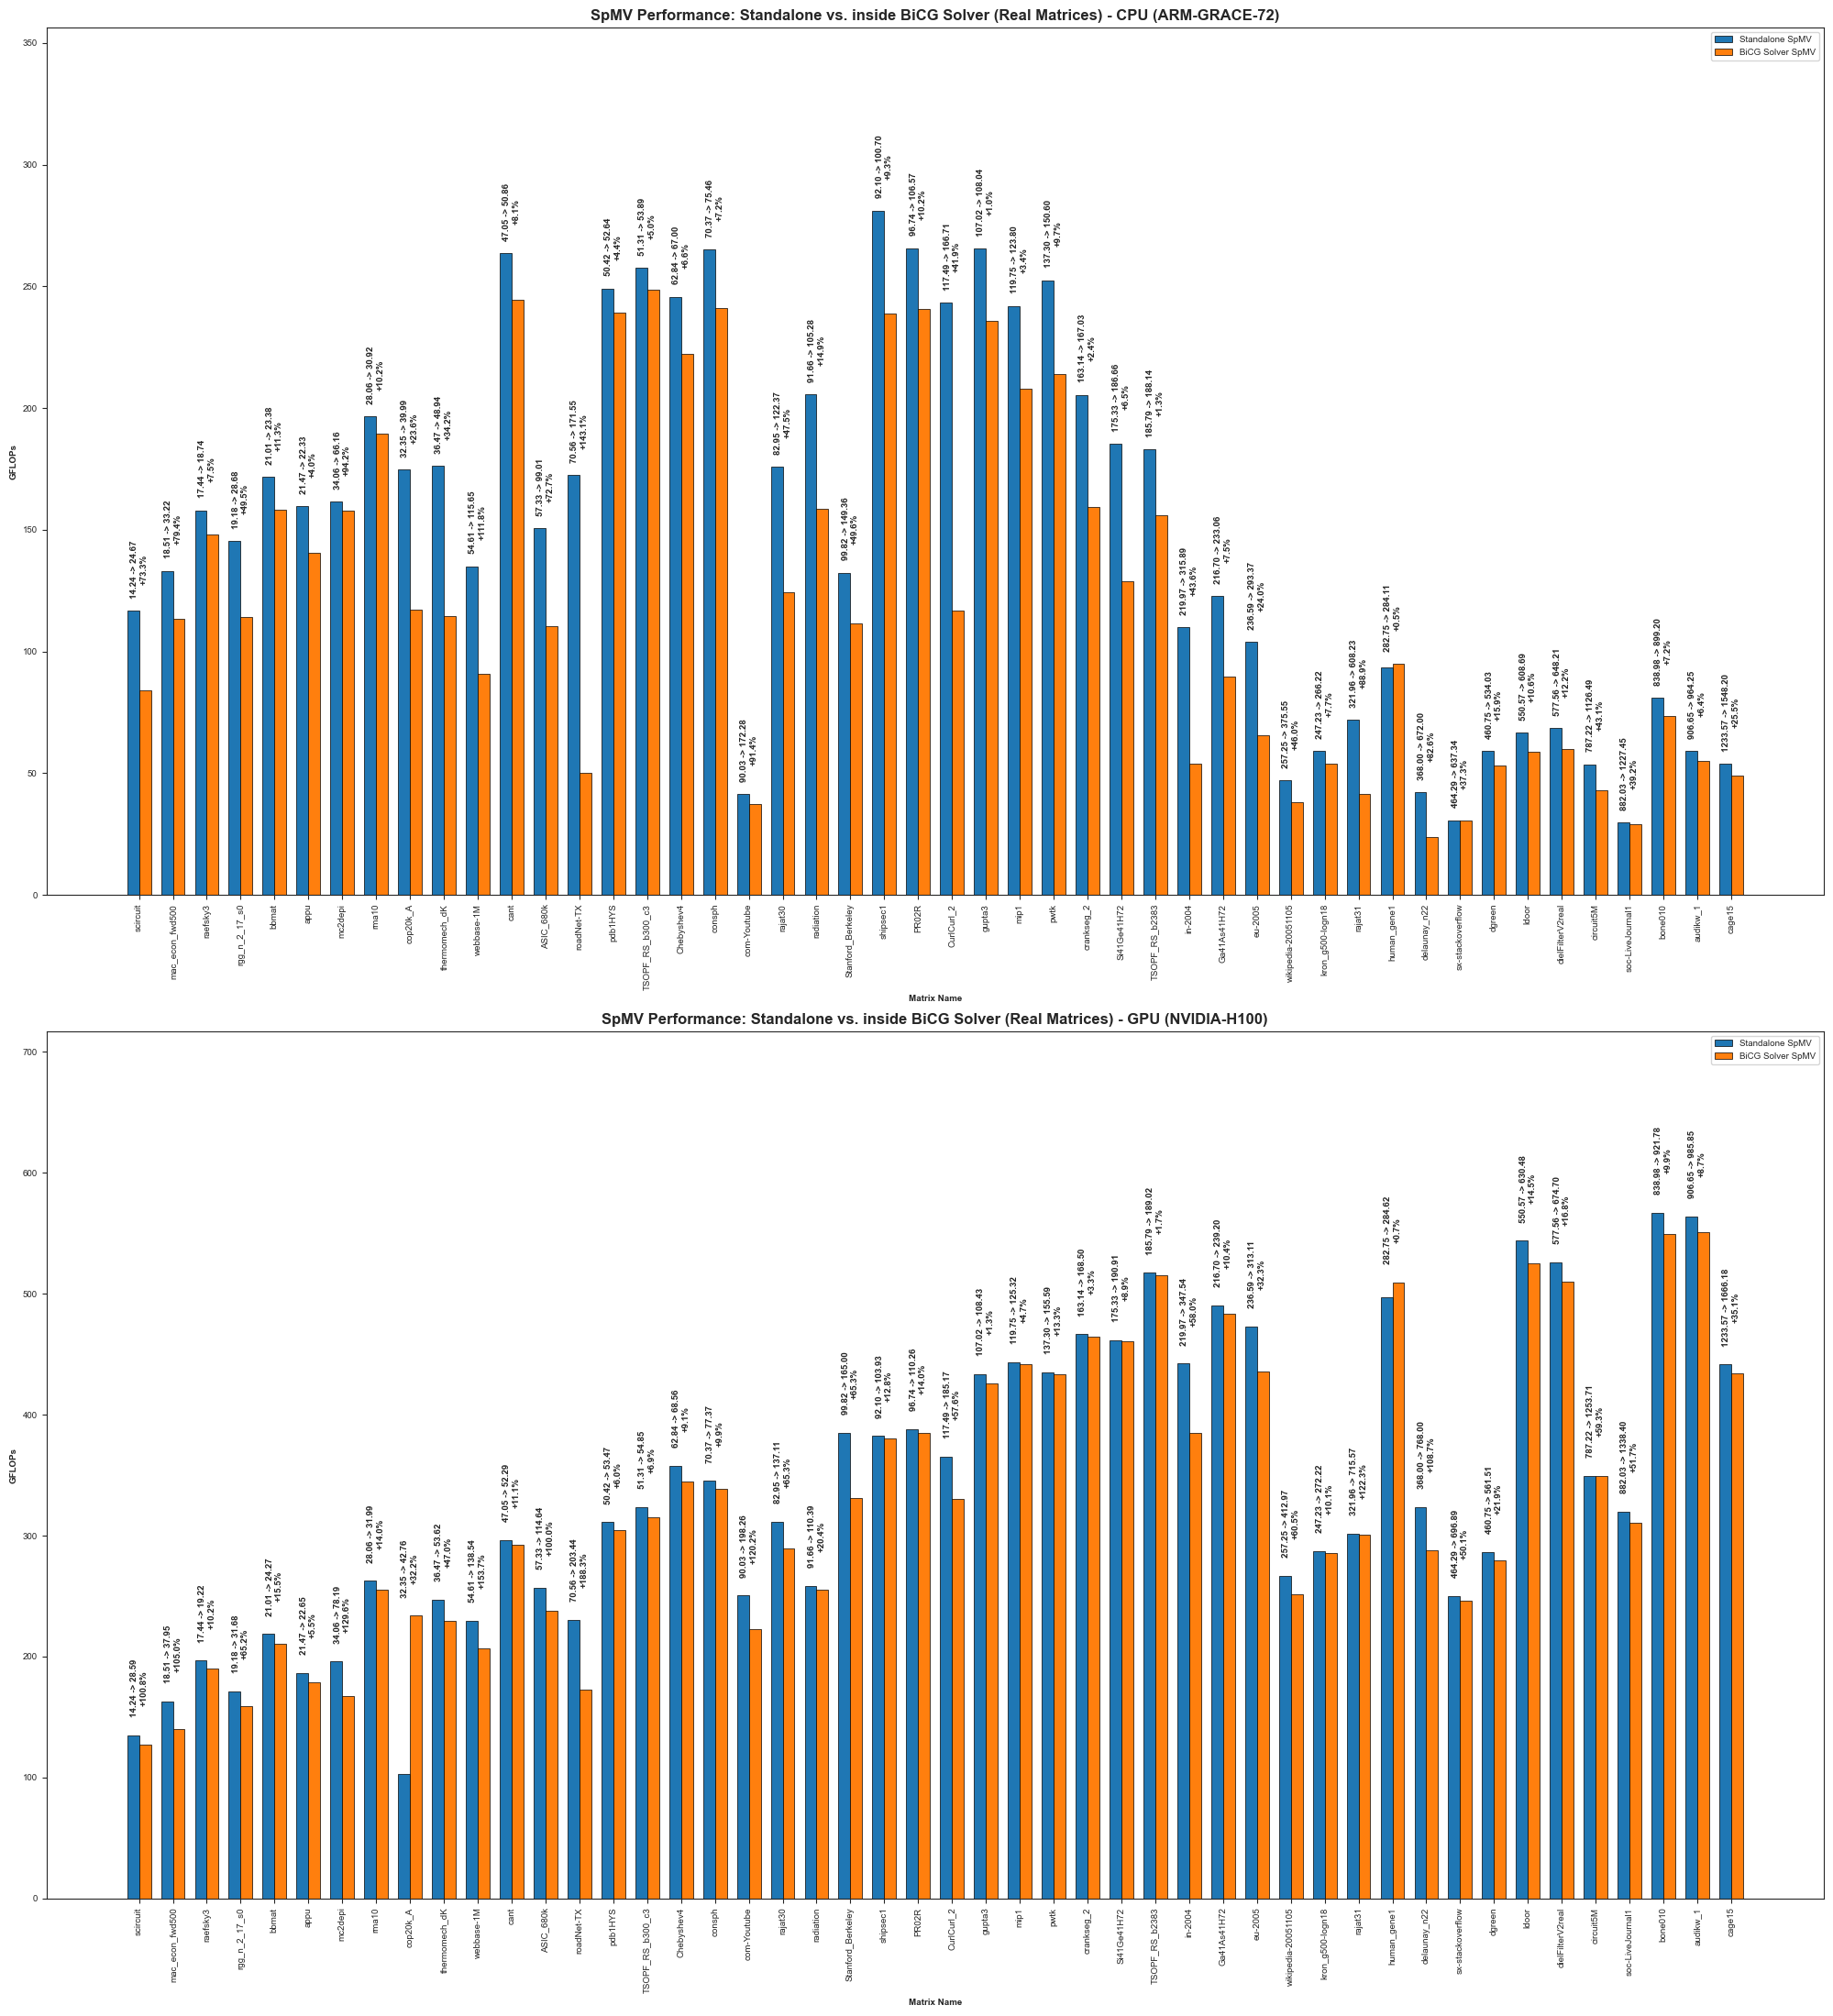

In [8]:
def draw_gflops_comparison_subplot(ax, df, title, is_gpu):
    x = np.arange(len(df))
    width = 0.35
    
    ax.bar(x - width/2, df['standalone_gflops'], width, label='Standalone SpMV', color='#1f77b4', edgecolor='black', linewidth=0.5)
    ax.bar(x + width/2, df['bicg_gflops'], width, label='BiCG Solver SpMV', color='#ff7f0e', edgecolor='black', linewidth=0.5)
    
    for idx, (ws_stand, ws_bc, ws_pct, gfl_stand, gfl_bc) in enumerate(zip(
        df['standalone_working_set'], 
        df['bicg_working_set'], 
        df['working_set_change_pct'],
        df['standalone_gflops'],
        df['bicg_gflops']
    )):
        annotation_text = f"{ws_stand:.2f} -> {ws_bc:.2f}\n{ws_pct:+.1f}%"
        taller_bar_height = max(gfl_stand, gfl_bc)
        y_pos = taller_bar_height + (5.0 if not is_gpu else 15.0)
        
        ax.text(
            idx,
            y_pos,
            annotation_text,
            ha='center',
            va='bottom',
            fontsize=7,
            rotation=90,
            fontweight='semibold'
        )
        
    ax.set_ylim(0, df[['standalone_gflops', 'bicg_gflops']].max().max() + (75 if not is_gpu else 150))
    ax.set_xlabel('Matrix Name', fontweight='bold')
    ax.set_ylabel('GFLOPs', fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(df['matrix_name'], rotation=90)
    ax.legend()

fig, axes = plt.subplots(2, 1, figsize=(20, 22))
draw_gflops_comparison_subplot(axes[0], df_real_cpu, f"SpMV Performance: Standalone vs. inside BiCG Solver (Real Matrices) - CPU ({CPU_DEVICE})", False)
draw_gflops_comparison_subplot(axes[1], df_real_gpu, f"SpMV Performance: Standalone vs. inside BiCG Solver (Real Matrices) - GPU ({GPU_DEVICE})", True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'spmv_real_performance_comparison.png'), dpi=300)
plt.show()

---
## Performance (GFLOPs) Comparison: Synthetic Matrices

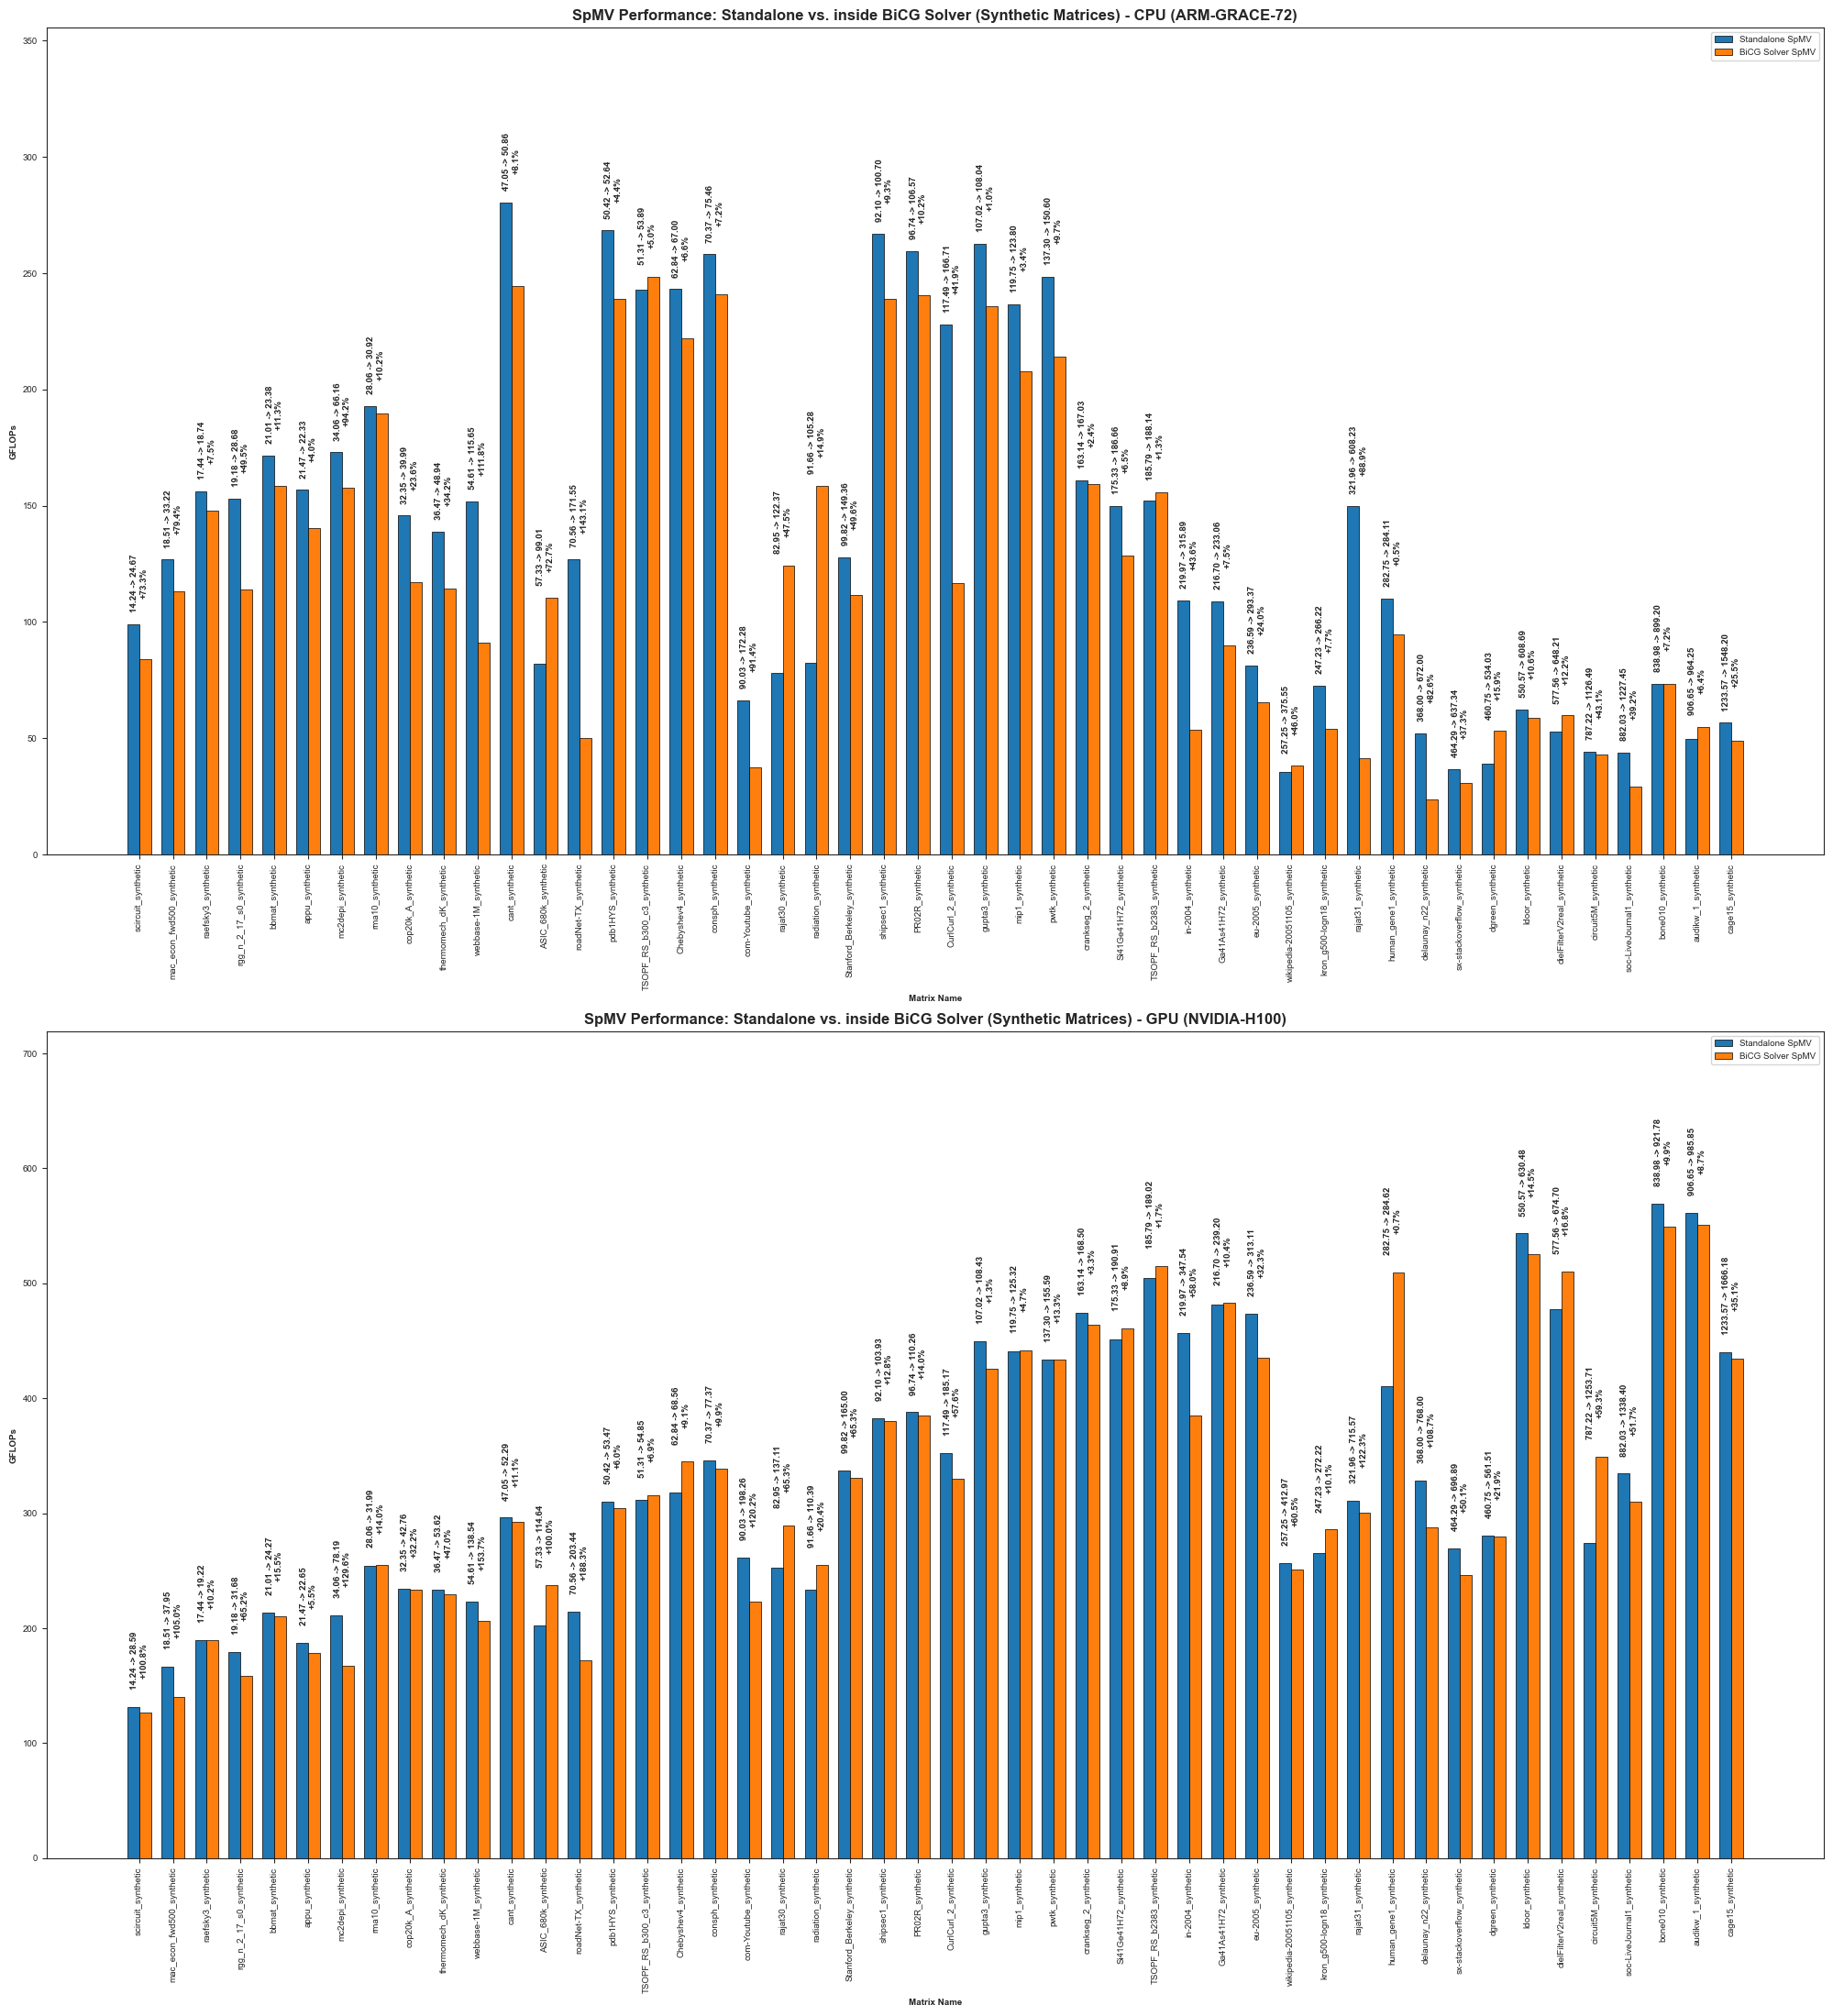

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(20, 22))
draw_gflops_comparison_subplot(axes[0], df_friend_cpu, f"SpMV Performance: Standalone vs. inside BiCG Solver (Synthetic Matrices) - CPU ({CPU_DEVICE})", False)
draw_gflops_comparison_subplot(axes[1], df_friend_gpu, f"SpMV Performance: Standalone vs. inside BiCG Solver (Synthetic Matrices) - GPU ({GPU_DEVICE})", True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'spmv_synthetic_performance_comparison.png'), dpi=300)
plt.show()

---
## Performance Change (%) Bar Charts: Real Matrices

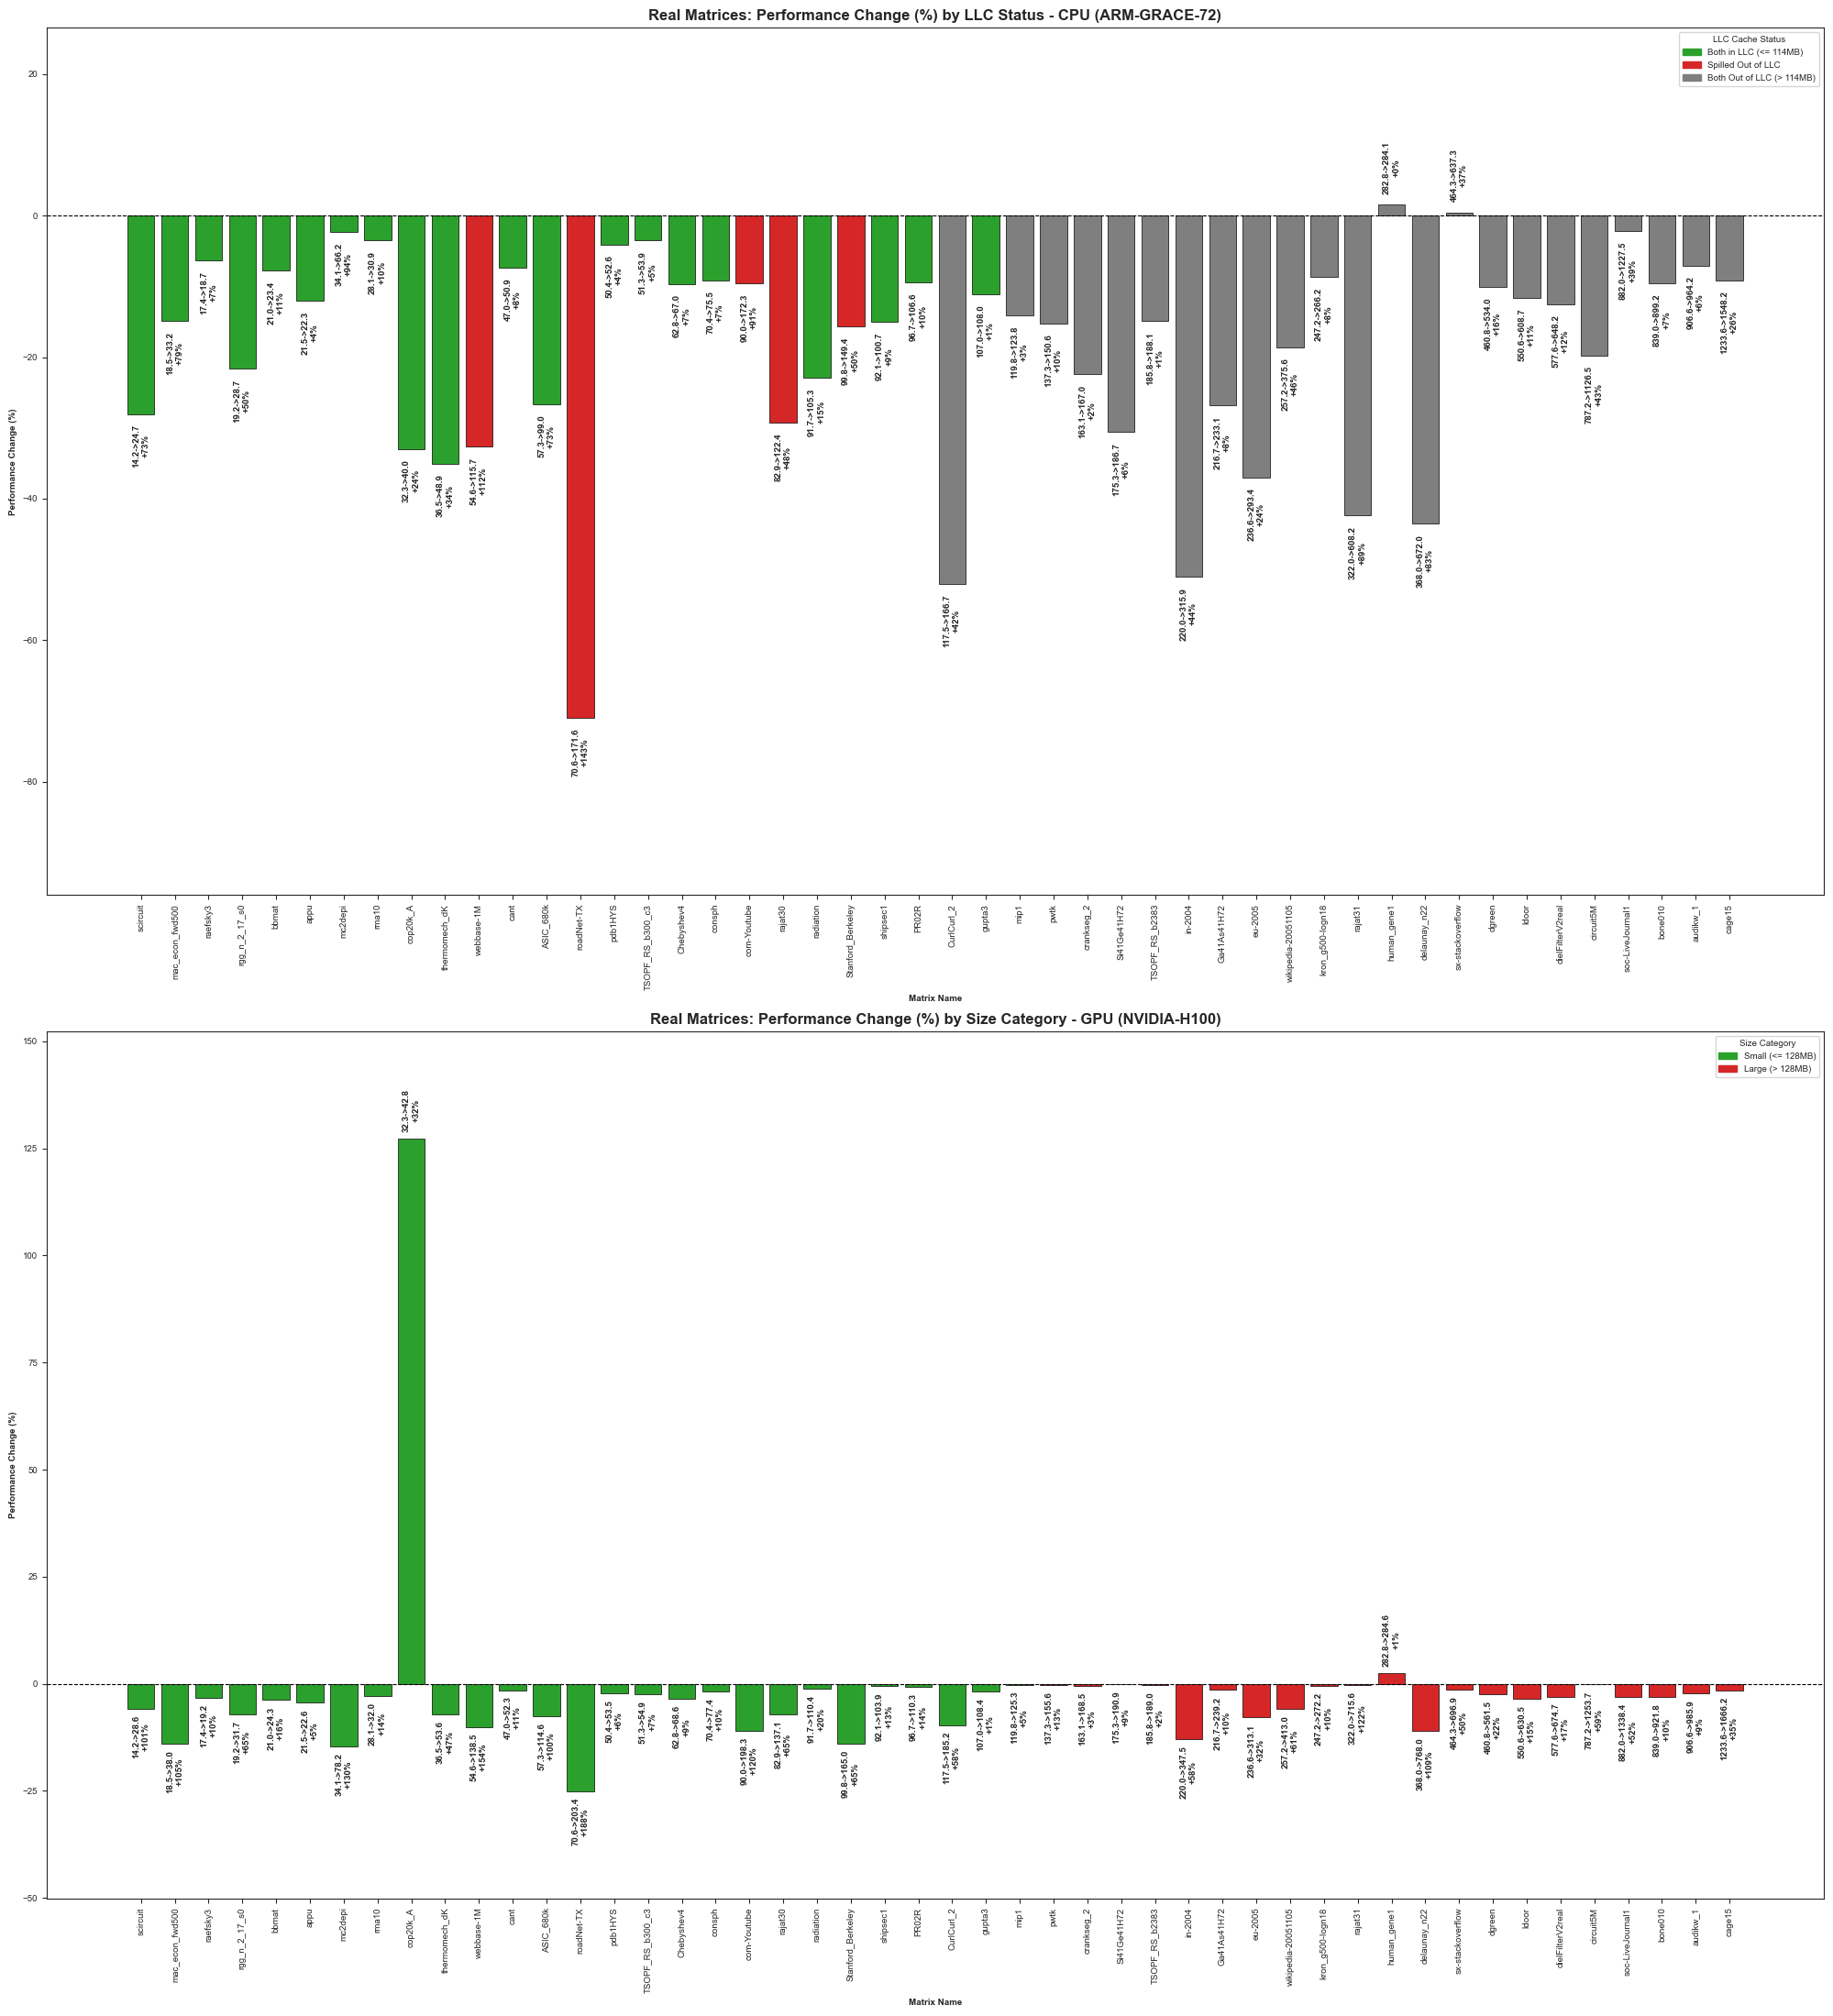

In [10]:
def draw_performance_change_subplot(ax, df, title, is_gpu):
    if is_gpu:
        color_map = {
            'Small (<= 128MB)': '#2ca02c',
            'Large (> 128MB)': '#d62728'
        }
    else:
        color_map = {
            'Both in LLC': '#2ca02c',
            'LLC Spill (In -> Out)': '#d62728',
            'Both Out of LLC': '#7f7f7f'
        }
        
    colors = [color_map[cat] for cat in df['cache_category']]
    x = np.arange(len(df))
    bars = ax.bar(x, df['gflops_change_pct'], color=colors, edgecolor='black', linewidth=0.5)
    
    for rect, ws_stand, ws_bc, ws_pct in zip(
        bars, 
        df['standalone_working_set'], 
        df['bicg_working_set'], 
        df['working_set_change_pct']
    ):
        height = rect.get_height()
        text = f"{ws_stand:.1f}->{ws_bc:.1f}\n{ws_pct:+.0f}%"
        va = 'bottom' if height >= 0 else 'top'
        y_pos = height + 1.5 if height >= 0 else height - 1.5
        ax.text(
            rect.get_x() + rect.get_width()/2.0, 
            y_pos, 
            text, 
            ha='center', 
            va=va, 
            fontsize=7, 
            rotation=90,
            fontweight='semibold'
        )
        
    y_min, y_max = df['gflops_change_pct'].min(), df['gflops_change_pct'].max()
    ax.set_ylim(y_min - 25, y_max + 25)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Matrix Name', fontweight='bold')
    ax.set_ylabel('Performance Change (%)', fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(df['matrix_name'], rotation=90)
    
    if is_gpu:
        handles = [
            mpatches.Patch(color='#2ca02c', label='Small (<= 128MB)'),
            mpatches.Patch(color='#d62728', label='Large (> 128MB)')
        ]
        legend_title = 'Size Category'
    else:
        handles = [
            mpatches.Patch(color='#2ca02c', label='Both in LLC (<= 114MB)'),
            mpatches.Patch(color='#d62728', label='Spilled Out of LLC'),
            mpatches.Patch(color='#7f7f7f', label='Both Out of LLC (> 114MB)')
        ]
        legend_title = 'LLC Cache Status'
    ax.legend(handles=handles, title=legend_title, loc='upper right')

fig, axes = plt.subplots(2, 1, figsize=(20, 22))
draw_performance_change_subplot(axes[0], df_real_cpu, f"Real Matrices: Performance Change (%) by LLC Status - CPU ({CPU_DEVICE})", False)
draw_performance_change_subplot(axes[1], df_real_gpu, f"Real Matrices: Performance Change (%) by Size Category - GPU ({GPU_DEVICE})", True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'spmv_real_performance_change_comparison.png'), dpi=300)
plt.show()

---
## Performance Change (%) Bar Charts: Synthetic Matrices

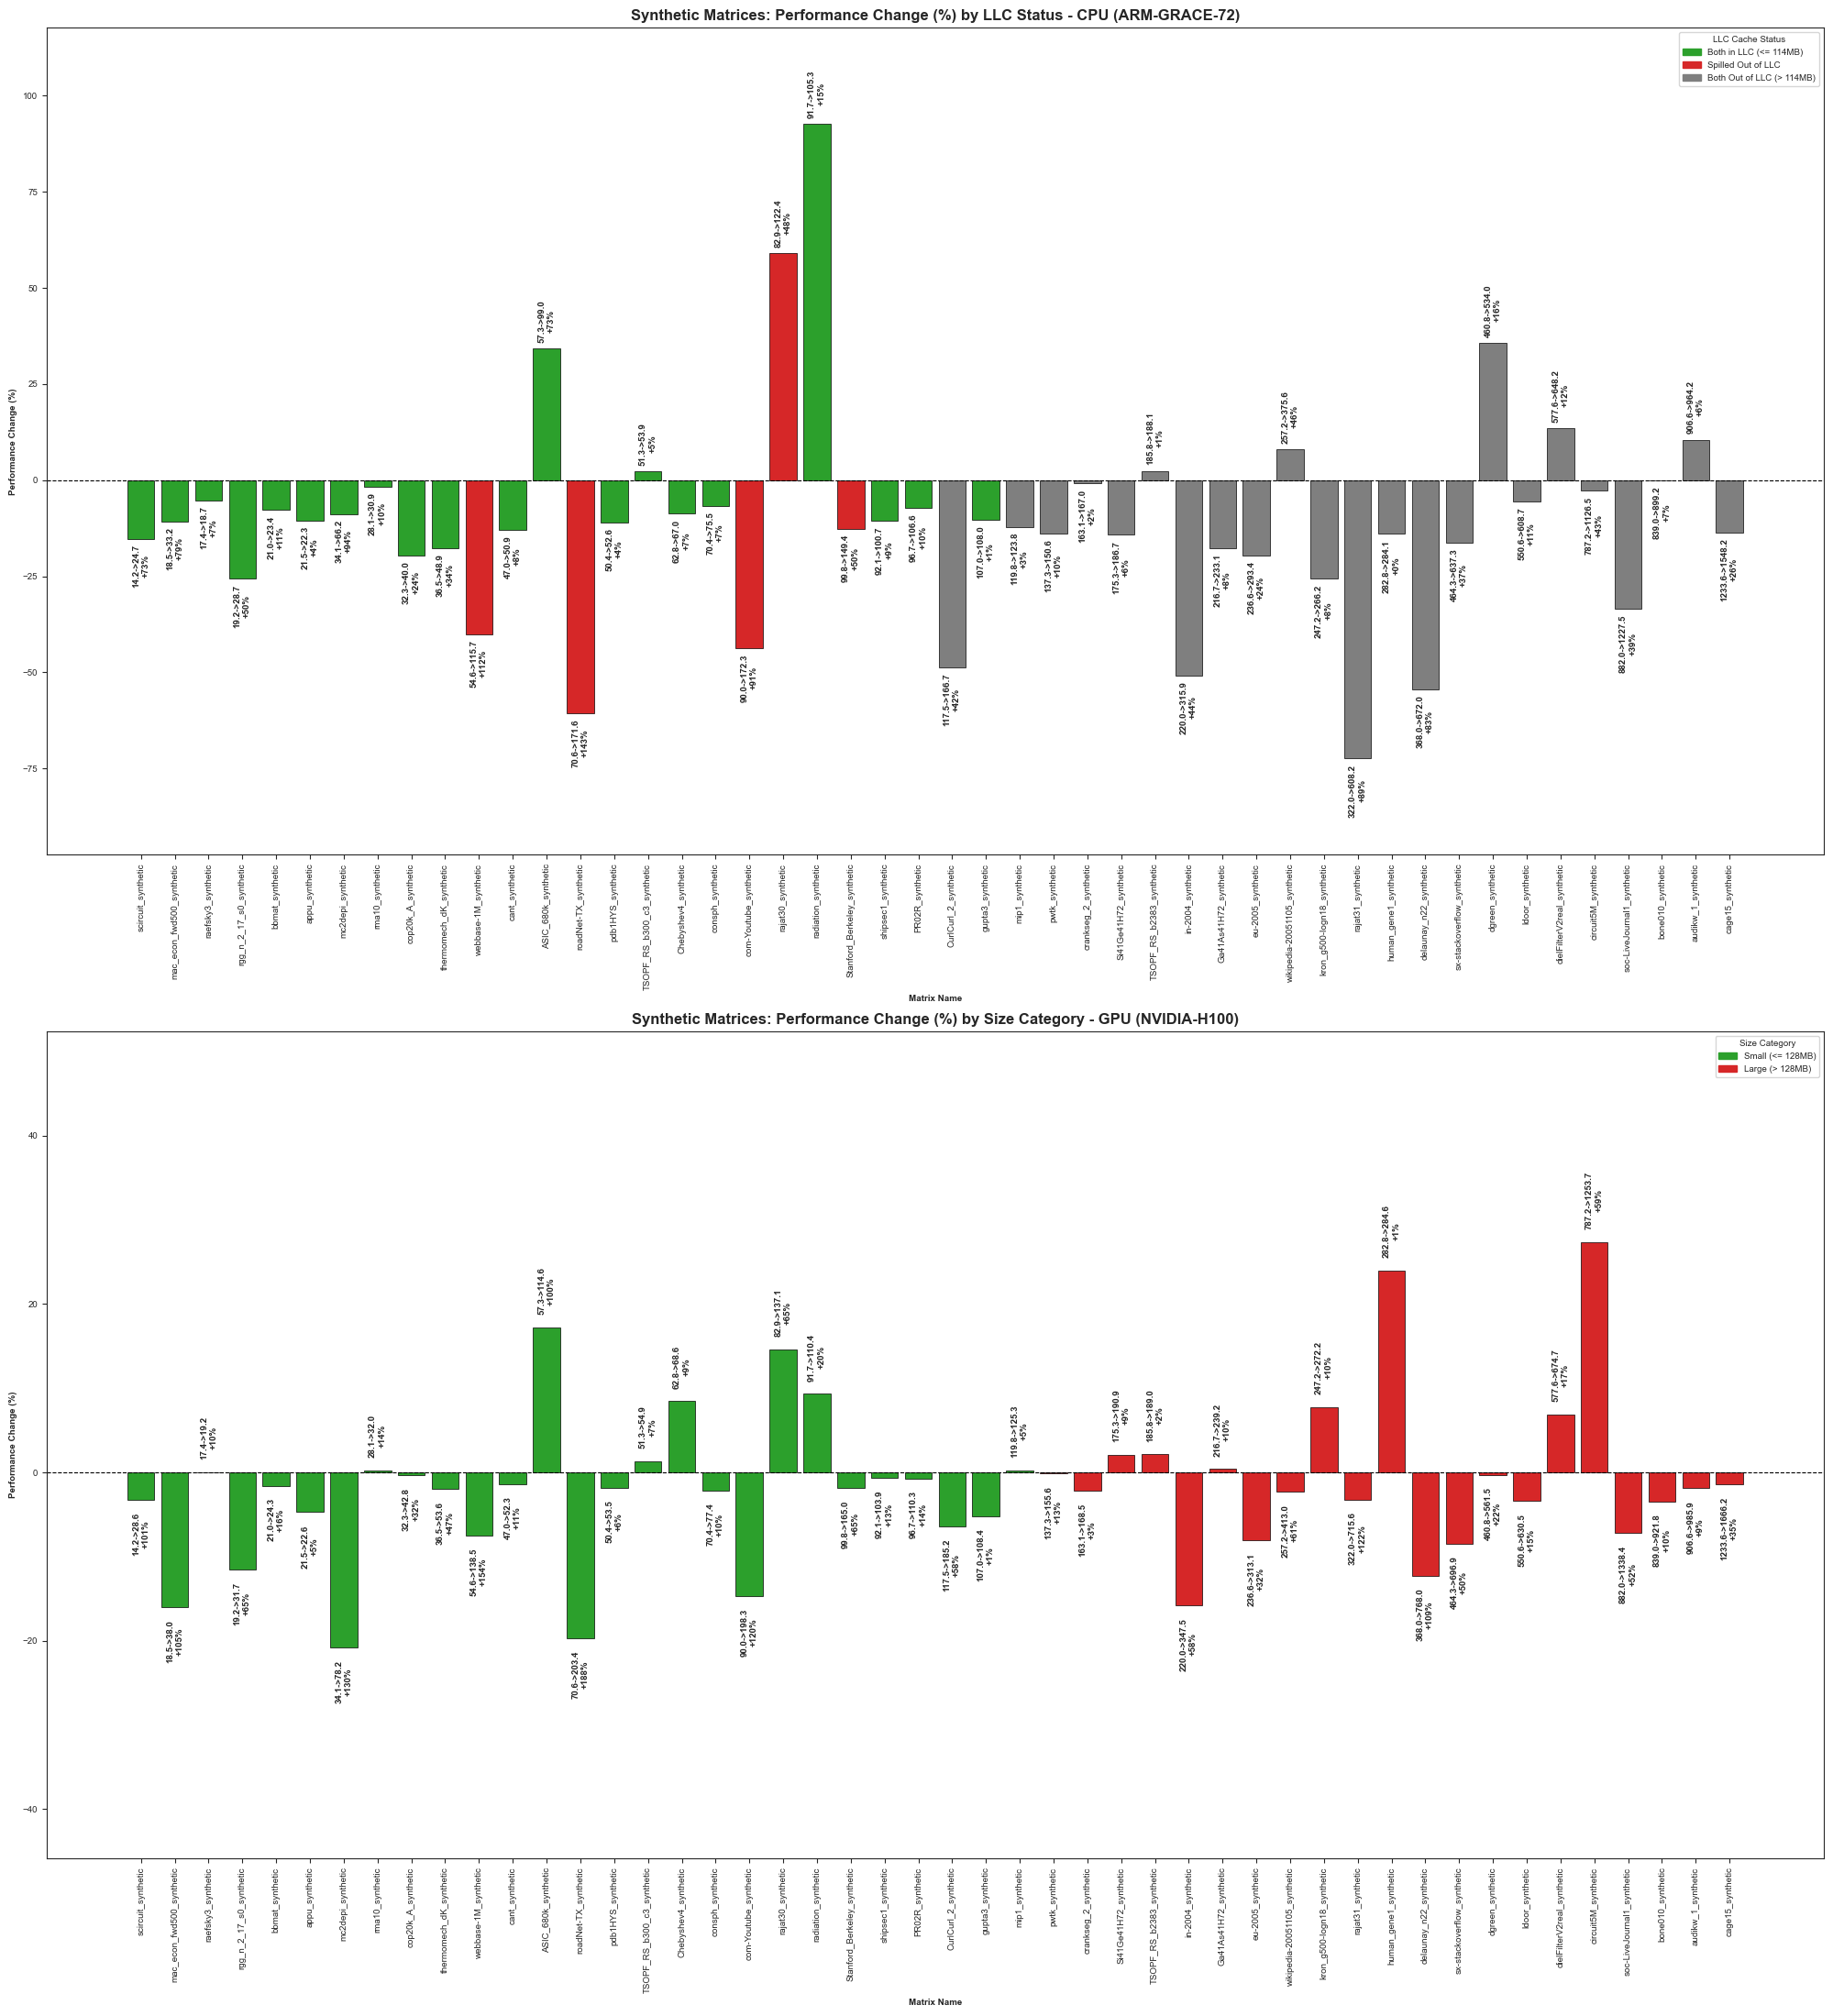

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(20, 22))
draw_performance_change_subplot(axes[0], df_friend_cpu, f"Synthetic Matrices: Performance Change (%) by LLC Status - CPU ({CPU_DEVICE})", False)
draw_performance_change_subplot(axes[1], df_friend_gpu, f"Synthetic Matrices: Performance Change (%) by Size Category - GPU ({GPU_DEVICE})", True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'spmv_synthetic_performance_change_comparison.png'), dpi=300)
plt.show()

---
## Combined Performance Change Comparison (Real vs. Synthetic)

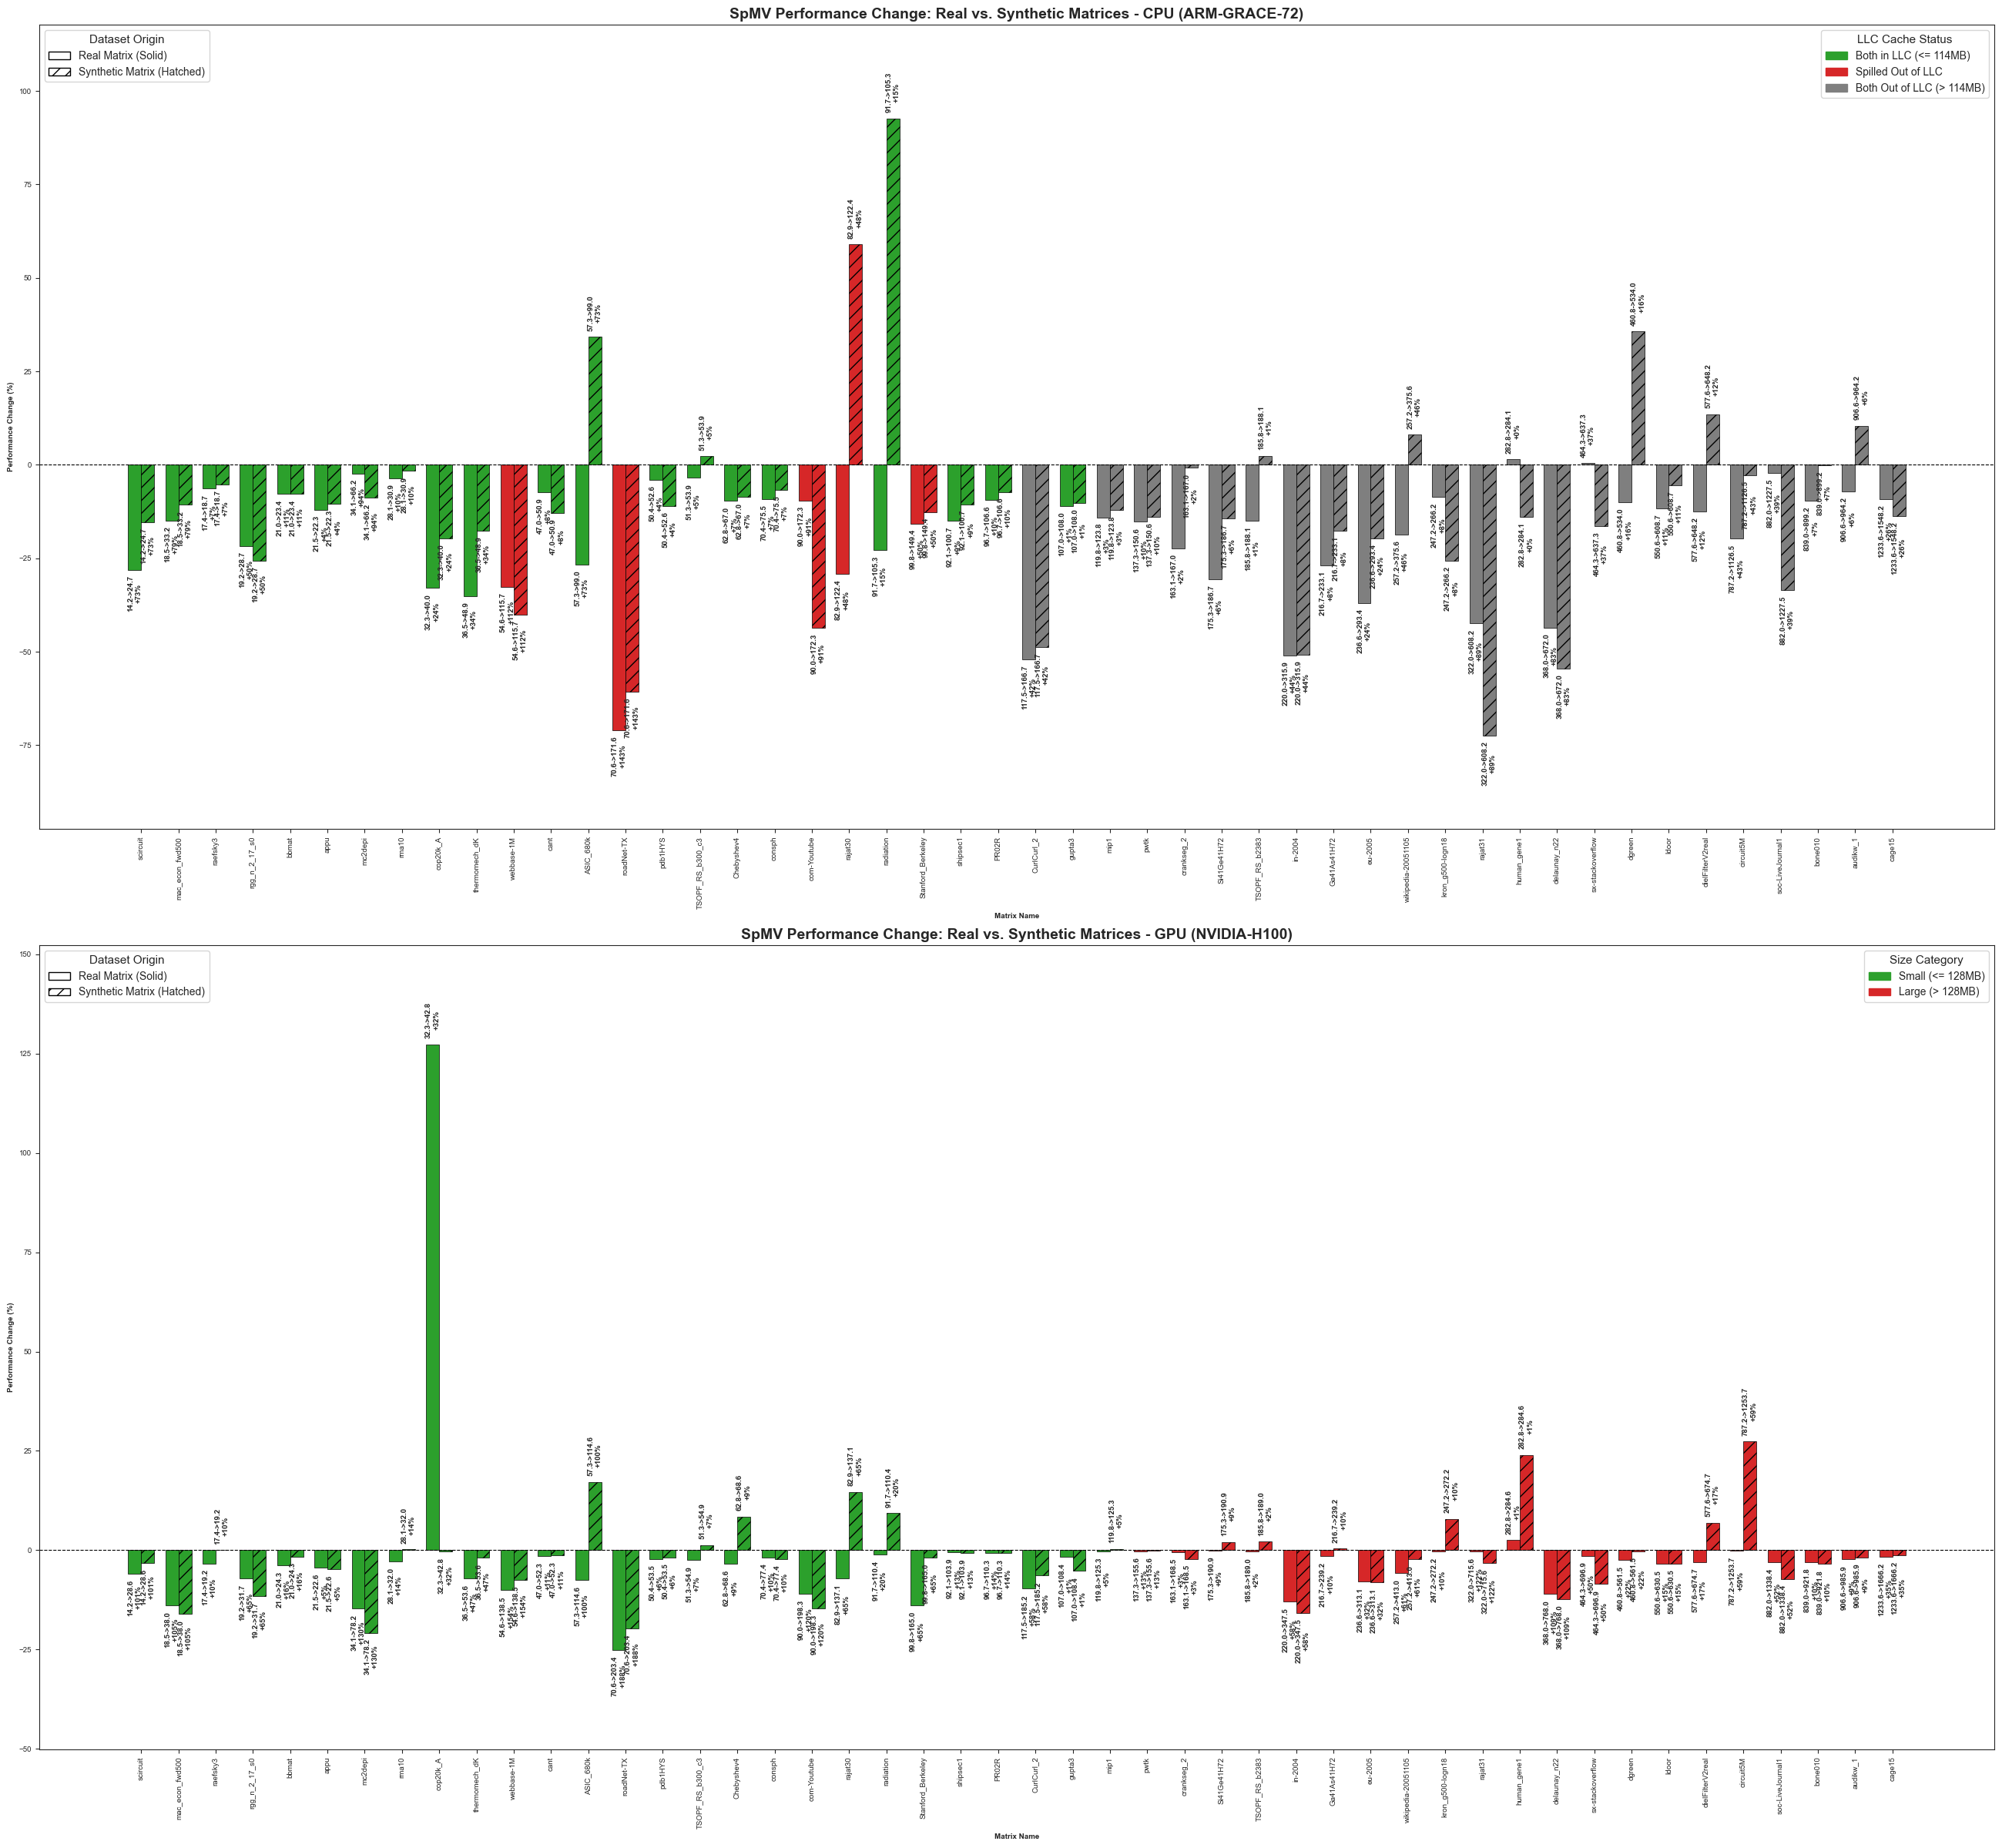

In [12]:
def draw_combined_performance_change_subplot(ax, df_real, df_friend, title, is_gpu):
    if is_gpu:
        color_map = {
            'Small (<= 128MB)': '#2ca02c',
            'Large (> 128MB)': '#d62728'
        }
    else:
        color_map = {
            'Both in LLC': '#2ca02c',
            'LLC Spill (In -> Out)': '#d62728',
            'Both Out of LLC': '#7f7f7f'
        }
        
    real_colors = [color_map[cat] for cat in df_real['cache_category']]
    friend_colors = [color_map[cat] for cat in df_friend['cache_category']]
    
    x = np.arange(len(df_real))
    width = 0.35
    
    bars_real = ax.bar(
        x - width/2, 
        df_real['gflops_change_pct'], 
        width, 
        color=real_colors, 
        edgecolor='black', 
        linewidth=0.5,
        label='Real Matrix'
    )
    
    bars_synth = ax.bar(
        x + width/2, 
        df_friend['gflops_change_pct'], 
        width, 
        color=friend_colors, 
        hatch='//', 
        edgecolor='black', 
        linewidth=0.5,
        label='Synthetic Matrix'
    )
    
    def annotate_bars(bars, df_data):
        for rect, ws_stand, ws_bc, ws_pct in zip(
            bars, 
            df_data['standalone_working_set'], 
            df_data['bicg_working_set'], 
            df_data['working_set_change_pct']
        ):
            height = rect.get_height()
            text = f"{ws_stand:.1f}->{ws_bc:.1f}\n{ws_pct:+.0f}%"
            va = 'bottom' if height >= 0 else 'top'
            y_pos = height + 1.5 if height >= 0 else height - 1.5
            ax.text(
                rect.get_x() + rect.get_width()/2.0, 
                y_pos, 
                text, 
                ha='center', 
                va=va, 
                fontsize=7, 
                rotation=90, 
                fontweight='semibold'
            )
            
    annotate_bars(bars_real, df_real)
    annotate_bars(bars_synth, df_friend)
    
    y_all = pd.concat([df_real['gflops_change_pct'], df_friend['gflops_change_pct']])
    y_min, y_max = y_all.min(), y_all.max()
    ax.set_ylim(y_min - 25, y_max + 25)
    
    if is_gpu:
        handles = [
            mpatches.Patch(color='#2ca02c', label='Small (<= 128MB)'),
            mpatches.Patch(color='#d62728', label='Large (> 128MB)')
        ]
        legend_title = 'Size Category'
    else:
        handles = [
            mpatches.Patch(color='#2ca02c', label='Both in LLC (<= 114MB)'),
            mpatches.Patch(color='#d62728', label='Spilled Out of LLC'),
            mpatches.Patch(color='#7f7f7f', label='Both Out of LLC (> 114MB)')
        ]
        legend_title = 'LLC Cache Status'
        
    dataset_handles = [
        mpatches.Patch(facecolor='white', edgecolor='black', label='Real Matrix (Solid)'),
        mpatches.Patch(facecolor='white', edgecolor='black', hatch='//', label='Synthetic Matrix (Hatched)')
    ]
    
    first_legend = ax.legend(handles=handles, title=legend_title, loc='upper right', fontsize=10, title_fontsize=11)
    ax.add_artist(first_legend)
    ax.legend(handles=dataset_handles, title='Dataset Origin', loc='upper left', fontsize=10, title_fontsize=11)
    
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Matrix Name', fontweight='bold')
    ax.set_ylabel('Performance Change (%)', fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(df_real['matrix_name'], rotation=90)

fig, axes = plt.subplots(2, 1, figsize=(26, 24))
draw_combined_performance_change_subplot(axes[0], df_real_cpu, df_friend_cpu, f"SpMV Performance Change: Real vs. Synthetic Matrices - CPU ({CPU_DEVICE})", False)
draw_combined_performance_change_subplot(axes[1], df_real_gpu, df_friend_gpu, f"SpMV Performance Change: Real vs. Synthetic Matrices - GPU ({GPU_DEVICE})", True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'spmv_combined_performance_change_comparison.png'), dpi=300)
plt.show()

---
## Performance Change vs. Working Set Change Scatter Plots: Real Matrices

In [13]:
def draw_scatter_change_subplot(ax, df, title, is_gpu):
    if is_gpu:
        color_map = {
            'Small (<= 128MB)': '#2ca02c',
            'Large (> 128MB)': '#d62728'
        }
    else:
        color_map = {
            'Both in LLC': '#2ca02c',
            'LLC Spill (In -> Out)': '#d62728',
            'Both Out of LLC': '#7f7f7f'
        }
        
    for cat, color in color_map.items():
        subset = df[df['cache_category'] == cat]
        if not subset.empty:
            ax.scatter(
                subset['working_set_change_pct'], 
                subset['gflops_change_pct'], 
                color=color, 
                label=cat, 
                s=70, 
                edgecolor='black', 
                linewidth=0.5,
                alpha=0.85
            )
            
    if len(df) > 1:
        m, b = np.polyfit(df['working_set_change_pct'], df['gflops_change_pct'], 1)
        x_vals = np.linspace(df['working_set_change_pct'].min() - 5, df['working_set_change_pct'].max() + 5, 100)
        ax.plot(x_vals, m * x_vals + b, color='#1f77b4', linestyle='--', linewidth=1.2, label=f'Trend (Slope: {m:.2f})')
        
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Working Set Change (%)', fontweight='bold')
    ax.set_ylabel('GFLOPs Change (%)', fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(title='Size Category' if is_gpu else 'LLC Cache Status', frameon=True)

# fig, axes = plt.subplots(2, 1, figsize=(11, 14))
# draw_scatter_change_subplot(axes[0], df_real_cpu, f"Real Matrices: GFLOPs Change vs. Working Set Change - CPU ({CPU_DEVICE})", False)
# draw_scatter_change_subplot(axes[1], df_real_gpu, f"Real Matrices: GFLOPs Change vs. Working Set Change - GPU ({GPU_DEVICE})", True)
# plt.tight_layout()
# plt.savefig(os.path.join(PLOT_DIR, 'performance_vs_workingset_real_change.png'), dpi=300)
# plt.show()

---
## Performance Change vs. Working Set Change Scatter Plots: Synthetic Matrices

In [14]:
# fig, axes = plt.subplots(2, 1, figsize=(11, 14))
# draw_scatter_change_subplot(axes[0], df_friend_cpu, f"Synthetic Matrices: GFLOPs Change vs. Working Set Change - CPU ({CPU_DEVICE})", False)
# draw_scatter_change_subplot(axes[1], df_friend_gpu, f"Synthetic Matrices: GFLOPs Change vs. Working Set Change - GPU ({GPU_DEVICE})", True)
# plt.tight_layout()
# plt.savefig(os.path.join(PLOT_DIR, 'performance_vs_workingset_synthetic_change.png'), dpi=300)
# plt.show()

---
## LLC Residency Analysis using Boxplots: Performance Change (%)

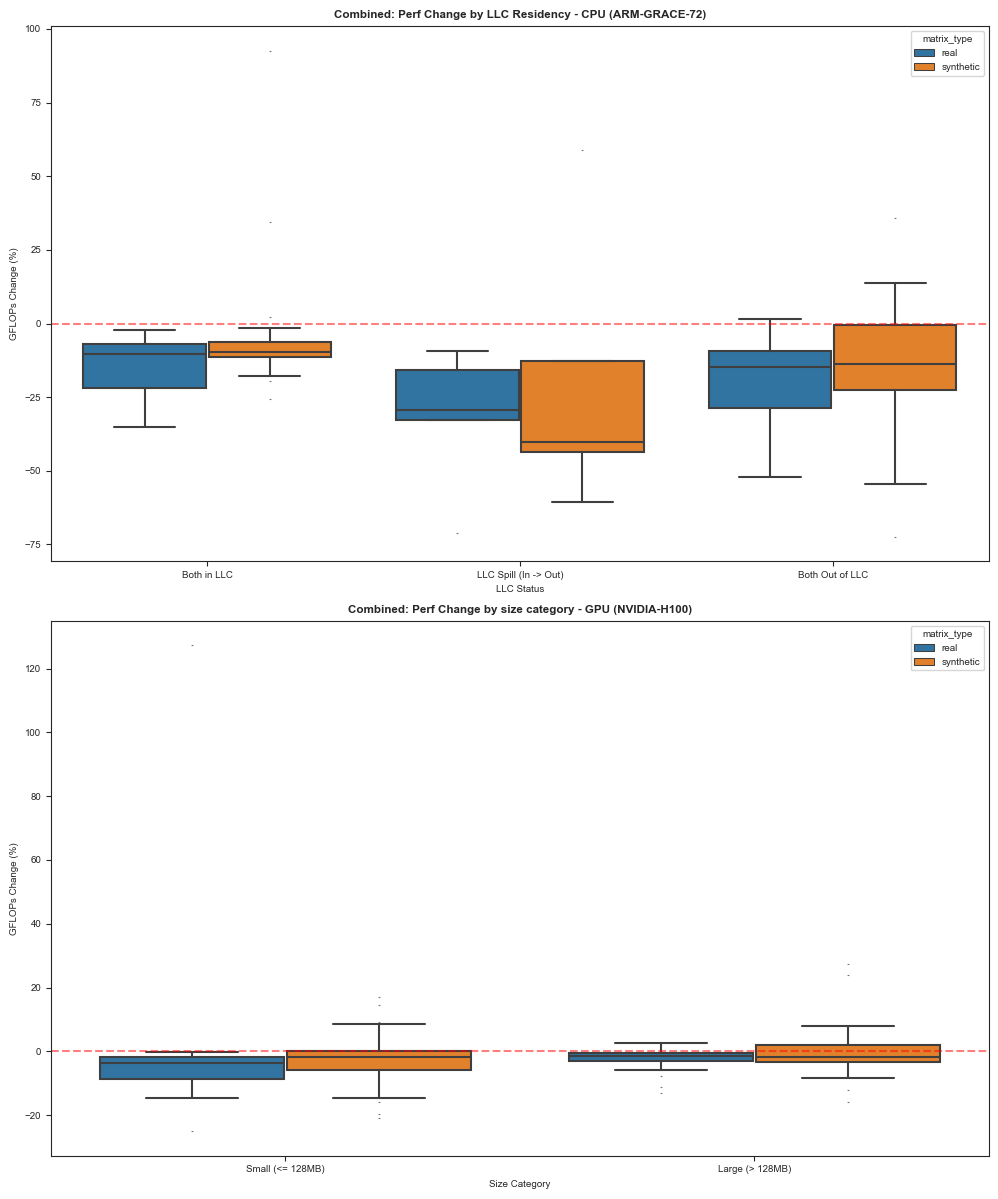

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(10, 12))

# CPU
df_cpu = df_combined_all[df_combined_all['device'] == CPU_DEVICE]
sns.boxplot(ax=axes[0], data=df_cpu, x='cache_category', y='gflops_change_pct', hue='matrix_type', order=['Both in LLC', 'LLC Spill (In -> Out)', 'Both Out of LLC'])
axes[0].set_title(f"Combined: Perf Change by LLC Residency - CPU ({CPU_DEVICE})", fontweight='bold')
axes[0].set_xlabel("LLC Status")
axes[0].set_ylabel("GFLOPs Change (%)")
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)

# GPU
df_gpu = df_combined_all[df_combined_all['device'] == GPU_DEVICE]
sns.boxplot(ax=axes[1], data=df_gpu, x='cache_category', y='gflops_change_pct', hue='matrix_type', order=['Small (<= 128MB)', 'Large (> 128MB)'])
axes[1].set_title(f"Combined: Perf Change by size category - GPU ({GPU_DEVICE})", fontweight='bold')
axes[1].set_xlabel("Size Category")
axes[1].set_ylabel("GFLOPs Change (%)")
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'spmv_llc_performance_change_boxplot.png'), dpi=300)
plt.show()

---
## LLC Residency Analysis using Boxplots: Performance Ratio

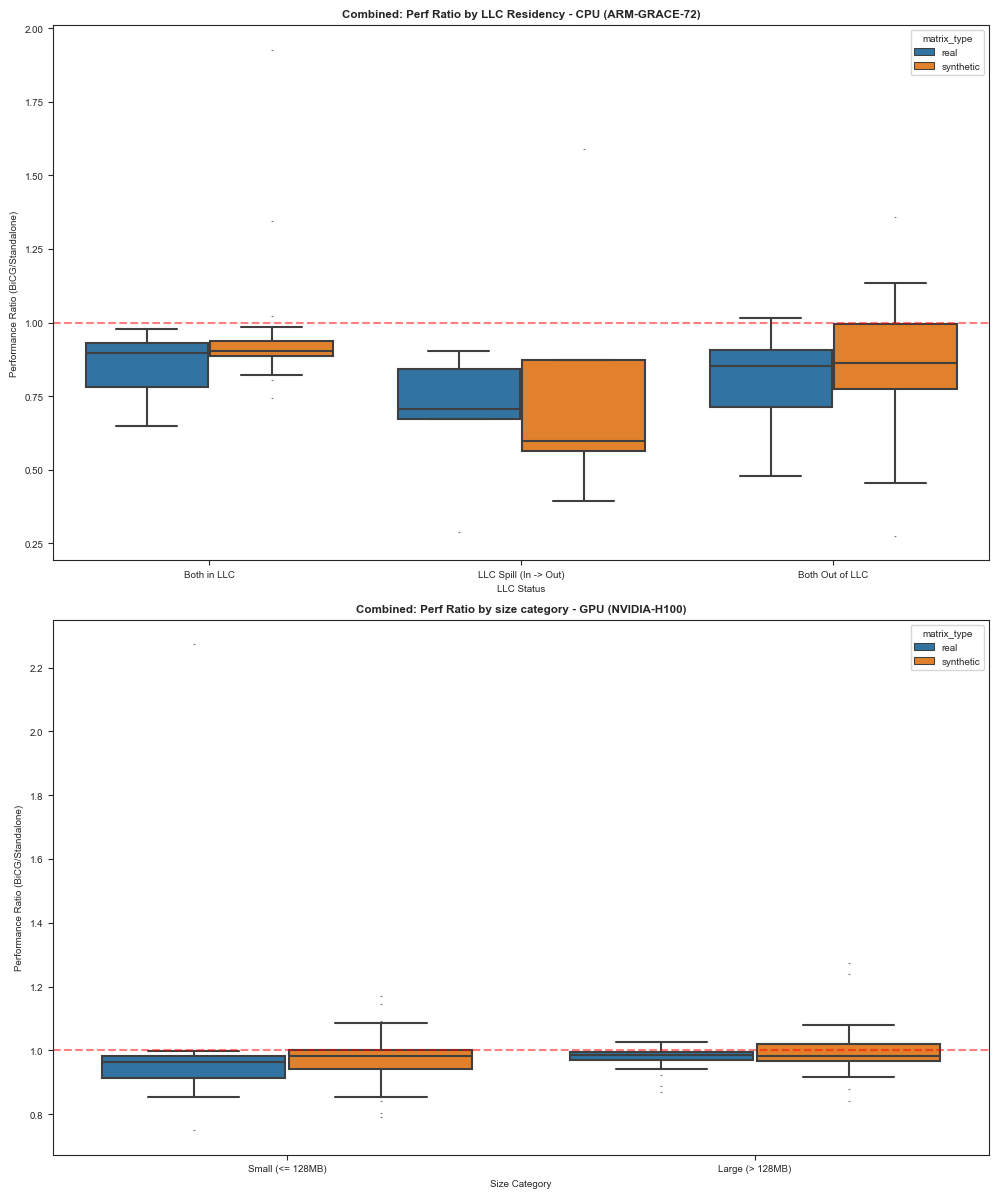

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(10, 12))

# CPU
df_cpu = df_combined_all[df_combined_all['device'] == CPU_DEVICE].copy()
sns.boxplot(ax=axes[0], data=df_cpu, x='cache_category', y='perf_ratio', hue='matrix_type', order=['Both in LLC', 'LLC Spill (In -> Out)', 'Both Out of LLC'])
axes[0].set_title(f"Combined: Perf Ratio by LLC Residency - CPU ({CPU_DEVICE})", fontweight='bold')
axes[0].set_xlabel("LLC Status")
axes[0].set_ylabel("Performance Ratio (BiCG/Standalone)")
axes[0].axhline(1, color='red', linestyle='--', alpha=0.5)

# GPU
df_gpu = df_combined_all[df_combined_all['device'] == GPU_DEVICE].copy()
sns.boxplot(ax=axes[1], data=df_gpu, x='cache_category', y='perf_ratio', hue='matrix_type', order=['Small (<= 128MB)', 'Large (> 128MB)'])
axes[1].set_title(f"Combined: Perf Ratio by size category - GPU ({GPU_DEVICE})", fontweight='bold')
axes[1].set_xlabel("Size Category")
axes[1].set_ylabel("Performance Ratio (BiCG/Standalone)")
axes[1].axhline(1, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'spmv_llc_performance_ratio_boxplot.png'), dpi=300)
plt.show()

---
## Real & Synthetic Dataset Performance Summarization

Below we generate and display a summary of how SpMV performance inside the BiCG solver is affected on each device architecture (grouped by device, matrix origin type, and size/cache category).

In [17]:
summary_real = df_combined_all.groupby(['device', 'matrix_type', 'cache_category']).agg(
    count=('gflops_change_pct', 'count'),
    mean_gflops_change_pct=('gflops_change_pct', 'mean'),
    median_gflops_change_pct=('gflops_change_pct', 'median'),
    min_gflops_change_pct=('gflops_change_pct', 'min'),
    max_gflops_change_pct=('gflops_change_pct', 'max'),
    mean_perf_ratio=('perf_ratio', 'mean'),
    pct_speedup=('gflops_change_pct', lambda x: (x > 0).sum() / len(x) * 100)
).reset_index()

summary_real.to_csv('spmv_real_summary.csv', index=False)
print("First part dataset summary successfully exported to spmv_real_summary.csv.")
summary_real

First part dataset summary successfully exported to spmv_real_summary.csv.


,device,matrix_type,cache_category,count,mean_gflops_change_pct,median_gflops_change_pct,min_gflops_change_pct,max_gflops_change_pct,mean_perf_ratio,pct_speedup
0,ARM-GRACE-72,real,Both Out of LLC,23,-19.8694,-14.8949,-52.0311,1.5396,0.8013,8.6957
1,ARM-GRACE-72,real,Both in LLC,20,-14.1711,-10.3789,-35.0854,-2.3156,0.8583,0.0000
2,ARM-GRACE-72,real,LLC Spill (In -> Out),5,-31.6141,-29.2638,-70.9995,-9.5046,0.6839,0.0000
3,ARM-GRACE-72,synthetic,Both Out of LLC,23,-15.0317,-13.9067,-72.3727,35.7573,0.8497,21.7391
4,ARM-GRACE-72,synthetic,Both in LLC,20,-3.0315,-9.5077,-25.6026,92.6537,0.9697,15.0000
5,ARM-GRACE-72,synthetic,LLC Spill (In -> Out),5,-19.6009,-40.0889,-60.6405,59.0306,0.8040,20.0000
6,NVIDIA-H100,real,Large (> 128MB),21,-2.8016,-1.5777,-12.9535,2.5328,0.9720,4.7619
7,NVIDIA-H100,real,Small (<= 128MB),27,-1.3397,-3.7909,-25.1167,127.2753,0.9866,3.7037
8,NVIDIA-H100,synthetic,Large (> 128MB),21,0.0391,-1.8543,-15.7829,27.3520,1.0004,33.3333
9,NVIDIA-H100,synthetic,Small (<= 128MB),27,-2.6232,-1.7913,-20.8119,17.1789,0.9738,29.6296


---
## Per-Matrix Performance Details (CPU & GPU side-by-side)

Below we pivot the performance results to get exactly one row per matrix name/type, with side-by-side columns representing CPU and GPU metrics.

In [18]:
df_cpu_labeled = df_combined_all[df_combined_all['device'] == CPU_DEVICE].drop(columns=['device'])
df_gpu_labeled = df_combined_all[df_combined_all['device'] == GPU_DEVICE].drop(columns=['device'])

df_per_matrix = pd.merge(
    df_cpu_labeled,
    df_gpu_labeled,
    on=['matrix_name', 'matrix_type', 'm', 'n', 'nnz_original', 'nnz_bicg'],
    suffixes=('_CPU', '_GPU')
)

df_per_matrix.to_csv('spmv_per_matrix_summary.csv', index=False)
print("Per-matrix summary successfully exported to spmv_per_matrix_summary.csv.")
df_per_matrix

Per-matrix summary successfully exported to spmv_per_matrix_summary.csv.


,matrix_name,m,n,nnz_original,nnz_bicg,standalone_gflops_CPU,bicg_gflops_CPU,perf_ratio_CPU,standalone_working_set_CPU,bicg_working_set_CPU,gflops_change_pct_CPU,nnz_change_pct_CPU,working_set_change_pct_CPU,cache_category_CPU,matrix_type,standalone_gflops_GPU,bicg_gflops_GPU,perf_ratio_GPU,standalone_working_set_GPU,bicg_working_set_GPU,gflops_change_pct_GPU,nnz_change_pct_GPU,working_set_change_pct_GPU,cache_category_GPU
0,scircuit,170998,170998,958936,959020,116.6794,83.9582,0.7196,14.2390,24.6700,-28.0437,0.0088,73.2561,Both in LLC,real,134.8865,126.9765,0.9414,14.2390,28.5900,-5.8642,0.0088,100.7860,Small (<= 128MB)
1,mac_econ_fwd500,206500,206500,1273389,1457389,133.1635,113.3170,0.8510,18.5143,33.2200,-14.9039,14.4496,79.4290,Both in LLC,real,162.6458,139.9514,0.8605,18.5143,37.9500,-13.9533,14.4496,104.9768,Small (<= 128MB)
2,raefsky3,21200,21200,1488768,1488768,157.9310,147.9147,0.9366,17.4400,18.7400,-6.3422,0.0000,7.4541,Both in LLC,real,196.5828,190.0227,0.9666,17.4400,19.2200,-3.3371,0.0000,10.2064,Small (<= 128MB)
3,rgg_n_2_17_s0,131072,131072,1457506,1588578,145.4722,113.9796,0.7835,19.1800,28.6800,-21.6486,8.9929,49.5308,Both in LLC,real,171.0251,158.7863,0.9284,19.1800,31.6800,-7.1561,8.9929,65.1721,Small (<= 128MB)
4,bbmat,38744,38744,1771722,1771722,171.6844,158.3436,0.9223,21.0100,23.3800,-7.7705,0.0000,11.2803,Both in LLC,real,218.7044,210.4136,0.9621,21.0100,24.2700,-3.7909,0.0000,15.5164,Small (<= 128MB)
5,appu,14000,14000,1853104,1853104,159.6783,140.4331,0.8795,21.4700,22.3300,-12.0525,0.0000,4.0056,Both in LLC,real,186.7098,178.5148,0.9561,21.4700,22.6500,-4.3891,0.0000,5.4960,Small (<= 128MB)
6,mc2depi,525825,525825,2100225,2100225,161.5104,157.7706,0.9768,34.0600,66.1600,-2.3156,0.0000,94.2454,Both in LLC,real,195.8297,167.1084,0.8533,34.0600,78.1900,-14.6664,0.0000,129.5655,Small (<= 128MB)
7,rma10,46835,46835,2374001,2374001,196.5540,189.6267,0.9648,28.0600,30.9200,-3.5244,0.0000,10.1924,Both in LLC,real,262.6178,255.0384,0.9711,28.0600,31.9900,-2.8861,0.0000,14.0057,Small (<= 128MB)
8,cop20k_A,121192,121192,2624331,2645680,174.7775,117.1802,0.6705,32.3457,39.9900,-32.9547,0.8135,23.6332,Both in LLC,real,102.8353,233.7193,2.2728,32.3457,42.7600,127.2753,0.8135,32.1969,Small (<= 128MB)
9,thermomech_dK,204316,204316,2846228,2846228,176.2523,114.4135,0.6491,36.4700,48.9400,-35.0854,0.0000,34.1925,Both in LLC,real,246.8685,229.4248,0.9293,36.4700,53.6200,-7.0660,0.0000,47.0250,Small (<= 128MB)


---
# Large Synthetic Dataset (16,200 matrices) Analysis

We now compare standalone SpMV vs. BiCG solver SpMV for the large synthetic dataset across CPU and GPU configurations.

---
## Parse and average the BiCG output logs, aligning Standalone and BiCG row-by-row and create common dataframe (df_art_final)

In [19]:
def parse_large_synthetic(real_log_paths, standalone_paths, device_name, is_gpu):
    standalone_dfs = [pd.read_csv(p) for p in standalone_paths]
    df_stand_art = standalone_dfs[0].copy()
    df_stand_art['gflops'] = (standalone_dfs[0]['gflops'] + standalone_dfs[1]['gflops']) / 2.0
    
    bicg_runs_records = []
    for path in real_log_paths:
        with open(path, 'r') as f:
            content = f.read()
        blocks = content.split("File: ")[1:]
        records = []
        for block in blocks:
            lines = block.strip().split('\n')
            padding = 0
            bicg_gflops = None
            standalone_working_set_raw = None
            bicg_working_set = None
            for line in lines:
                if 'Adding' in line and 'missing diagonal nonzeros' in line:
                    padding = int(line.split()[1])
                elif 'SpMV: calls =' in line:
                    match = re.search(r'GFLOPs\s*=\s*([\d.]+),\s*WS_standalone\s*=\s*([\d.]+)\s*MB,\s*WS_bicg\s*=\s*([\d.]+)\s*MB', line)
                    if match:
                        bicg_gflops = float(match.group(1))
                        standalone_working_set_raw = float(match.group(2))
                        bicg_working_set = float(match.group(3))
                elif ',' in line:
                    csv_parts = line.split(',')
                    if len(csv_parts) >= 15 and csv_parts[11] in ['ARMPL', 'CUSPARSE_CSR']:
                        m = int(csv_parts[12])
                        n = int(csv_parts[13])
                        nnz_bicg = int(csv_parts[14])
            # Correction to performance: We must not take into account the padding!
            bicg_gflops_correct = bicg_gflops * (nnz_bicg - padding) / nnz_bicg
            bicg_gflops_wrong = bicg_gflops
            bicg_gflops = bicg_gflops_correct

            records.append({
                'padding': padding,
                'bicg_gflops': bicg_gflops,
                'standalone_working_set_raw': standalone_working_set_raw,
                'bicg_working_set': bicg_working_set
            })
        bicg_runs_records.append(records)
        
    num_records = min(len(r) for r in bicg_runs_records)
    avg_records = []
    for idx in range(num_records):
        rec1 = bicg_runs_records[0][idx]
        rec2 = bicg_runs_records[1][idx]
        avg_bicg_gflops = (rec1['bicg_gflops'] + rec2['bicg_gflops']) / 2.0
        avg_stand_ws_raw = (rec1['standalone_working_set_raw'] + rec2['standalone_working_set_raw']) / 2.0
        avg_bicg_ws = (rec1['bicg_working_set'] + rec2['bicg_working_set']) / 2.0
        avg_records.append({
            'padding': rec1['padding'],
            'bicg_gflops': avg_bicg_gflops,
            'standalone_working_set_raw': avg_stand_ws_raw,
            'bicg_working_set': avg_bicg_ws
        })
    df_bicg_art = pd.DataFrame(avg_records)
    
    df_stand_subset = df_stand_art.iloc[:len(df_bicg_art)].copy()
    df_stand_subset = df_stand_subset.rename(columns={
        'gflops': 'standalone_gflops',
        'nr_rows': 'm',
        'nr_cols': 'n',
        'nr_nzeros': 'nnz_original'
    })
    df_art_final = pd.concat([df_stand_subset.reset_index(drop=True), df_bicg_art.reset_index(drop=True)], axis=1)
    
    df_art_final['nnz_bicg'] = df_art_final['nnz_original'] + df_art_final['padding']
    padding_footprint_mb = (df_art_final['padding'] * 12) / (1024 * 1024)
    df_art_final['standalone_working_set'] = df_art_final['standalone_working_set_raw'] - padding_footprint_mb
    df_art_final['gflops_change_pct'] = ((df_art_final['bicg_gflops'] - df_art_final['standalone_gflops']) / df_art_final['standalone_gflops']) * 100
    df_art_final['working_set_change_pct'] = ((df_art_final['bicg_working_set'] - df_art_final['standalone_working_set']) / df_art_final['standalone_working_set']) * 100
    df_art_final['perf_ratio'] = df_art_final['bicg_gflops'] / df_art_final['standalone_gflops']
    
    df_art_final['m'] = df_art_final['m'].round().astype(int)
    df_art_final['n'] = df_art_final['n'].round().astype(int)
    df_art_final['nnz_original'] = df_art_final['nnz_original'].round().astype(int)
    df_art_final['nnz_bicg'] = df_art_final['nnz_bicg'].round().astype(int)
    df_art_final['padding'] = df_art_final['padding'].round().astype(int)
    
    limit = GPU_LLC_LIMIT if is_gpu else CPU_LLC_LIMIT
    def get_cache_cat_simple(row):
        ws_stand = row['standalone_working_set']
        if is_gpu:
            return 'Small (<= 128MB)' if ws_stand <= limit else 'Large (> 128MB)'
        else:
            ws_bc = row['bicg_working_set']
            if ws_stand <= limit and ws_bc <= limit:
                return 'Both in LLC'
            elif ws_stand <= limit and ws_bc > limit:
                return 'LLC Spill'
            else:
                return 'Both Out of LLC'
                
    df_art_final['cache_category'] = df_art_final.apply(get_cache_cat_simple, axis=1)
    df_art_final['device'] = device_name
    return df_art_final


In [20]:
# Ingest CPU Artificial
cpu_art_real_paths = ["Logs_CPU/bicg_armpl_artificial1.out", "Logs_CPU/bicg_armpl_artificial2.out"]
cpu_art_standalone_paths = ["Logs_CPU/standalone_armpl_artificial1.csv", "Logs_CPU/standalone_armpl_artificial2.csv", "Logs_CPU/standalone_armpl_artificial3.csv"]
df_art_cpu = parse_large_synthetic(cpu_art_real_paths, cpu_art_standalone_paths, CPU_DEVICE, False)

# Ingest GPU Artificial
gpu_art_real_paths = ["Logs_GPU/bicg_cusparse_csr_artificial1.out", "Logs_GPU/bicg_cusparse_csr_artificial2.out"]
gpu_art_standalone_paths = ["Logs_GPU/standalone_cusparse_csr_artificial1.csv", "Logs_GPU/standalone_cusparse_csr_artificial2.csv"]
df_art_gpu = parse_large_synthetic(gpu_art_real_paths, gpu_art_standalone_paths, GPU_DEVICE, True)

df_art_final_all = pd.concat([df_art_cpu, df_art_gpu], ignore_index=True)
print("Large Synthetic Dataset total rows:", len(df_art_final_all))

Large Synthetic Dataset total rows: 32380


---
## Do some feature categorization (like in synthetic.ipynb)

In [21]:
ranges_anr = ['[0-10]', '[10-50]', '[50-100]', '[100-510]']
ranges_skew = ['[0-1.5]', '[1.5-50]', '[50-250]', '[250-3000]', '[3000-10000]']
ranges_memr = ['[4-8]','[8-16]','[16-32]','[32-64]','[64-128]','[128-256]','[256-512]','[512-1024]','[1024-2048]']
ranges_regularity = ['SS', 'SL', 'LS', 'LL']

def set_category(x, cat_list):
    for cat in cat_list:
        parts = cat.strip('[]').split('-')
        cat_min = float(parts[0])
        cat_max = float(parts[1])
        if cat_min < x <= cat_max or (cat_min == 0.0 and x == 0.0):
            return cat
    return None

df_art_final_all['anr_categ'] = df_art_final_all['avg_nnz_per_row'].apply(lambda x: set_category(x, ranges_anr))
df_art_final_all['skew_categ'] = df_art_final_all['skew'].apply(lambda x: set_category(x, ranges_skew))

ranges_crs = ['[0-0.5]', '[0.5-1]']
ranges_ann = ['[0-1]', '[1-2]']
ranges_size = ['S', 'L']

def set_category_size(x, cat_list, cat_size):
    for idx, cat in enumerate(cat_list):
        parts = cat.strip('[]').split('-')
        cat_min = float(parts[0])
        cat_max = float(parts[1])
        if cat_min < x <= cat_max or (cat_min == 0.0 and x == 0.0):
            return cat_size[idx]
    return None

df_art_final_all['crs_categ'] = df_art_final_all['cross_row_similarity'].apply(lambda x: set_category_size(x, ranges_crs, ranges_size))
df_art_final_all['ann_categ'] = df_art_final_all['avg_num_neighbours'].apply(lambda x: set_category_size(x, ranges_ann, ranges_size))
df_art_final_all['regularity'] = df_art_final_all['crs_categ'] + df_art_final_all['ann_categ']
df_art_final_all['matrix_name'] = 'synthetic'

print("Categorization done.")

Categorization done.


---
## Melt the DataFrame to have standalone and bicg gflops in the same column for side-by-side comparison

In [22]:
df_gflops_melted = df_art_final_all.melt(
    id_vars=['cache_category', 'mem_range', 'anr_categ', 'skew_categ', 'regularity', 'device'],
    value_vars=['standalone_gflops', 'bicg_gflops'],
    var_name='Measurement_Type',
    value_name='GFLOPs'
)
df_gflops_melted['Measurement_Type'] = df_gflops_melted['Measurement_Type'].map({
    'standalone_gflops': 'Standalone SpMV',
    'bicg_gflops': 'BiCG SpMV'
})
print("Melt complete.")

Melt complete.


---
## Standalone vs BiCG GFLOPs on Large Synthetic Dataset

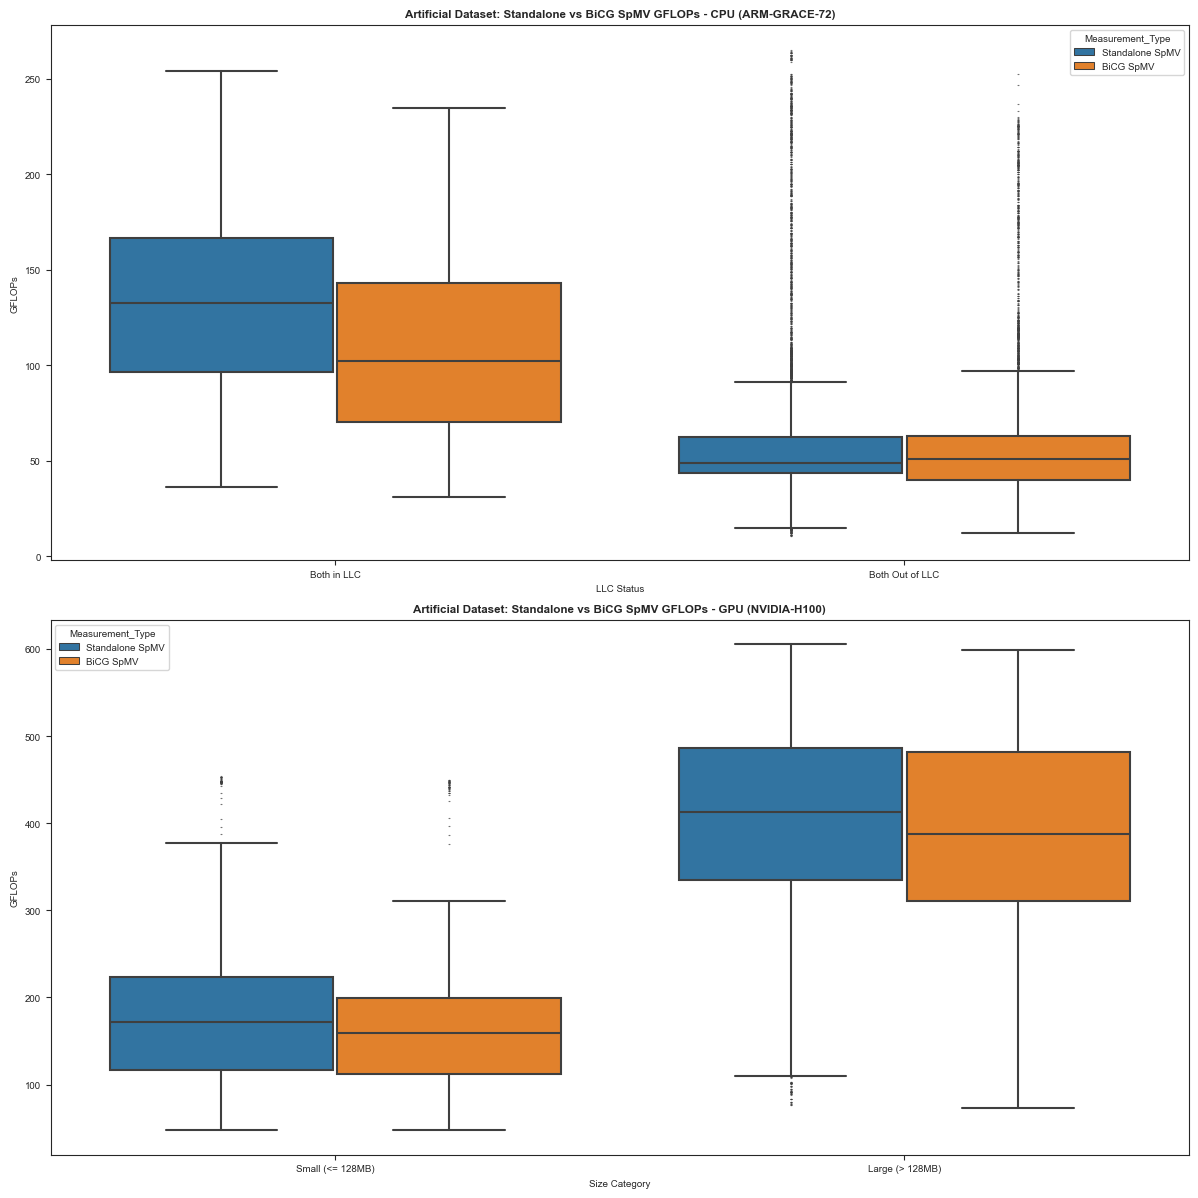

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

# CPU
df_cpu = df_gflops_melted[df_gflops_melted['device'] == CPU_DEVICE]
sns.boxplot(ax=axes[0], data=df_cpu, x='cache_category', y='GFLOPs', hue='Measurement_Type', palette={'Standalone SpMV': '#1f77b4', 'BiCG SpMV': '#ff7f0e'}, order=['Both in LLC', 'Both Out of LLC'])
axes[0].set_title(f"Artificial Dataset: Standalone vs BiCG SpMV GFLOPs - CPU ({CPU_DEVICE})", fontweight='bold')
axes[0].set_xlabel("LLC Status")
axes[0].set_ylabel("GFLOPs")

# GPU
df_gpu = df_gflops_melted[df_gflops_melted['device'] == GPU_DEVICE]
sns.boxplot(ax=axes[1], data=df_gpu, x='cache_category', y='GFLOPs', hue='Measurement_Type', palette={'Standalone SpMV': '#1f77b4', 'BiCG SpMV': '#ff7f0e'}, order=['Small (<= 128MB)', 'Large (> 128MB)'])
axes[1].set_title(f"Artificial Dataset: Standalone vs BiCG SpMV GFLOPs - GPU ({GPU_DEVICE})", fontweight='bold')
axes[1].set_xlabel("Size Category")
axes[1].set_ylabel("GFLOPs")

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'artificial_gflops_comparison_boxplot.png'), dpi=300)
plt.show()

---
## Standalone vs BiCG Performance Change (%) on Large Synthetic Dataset

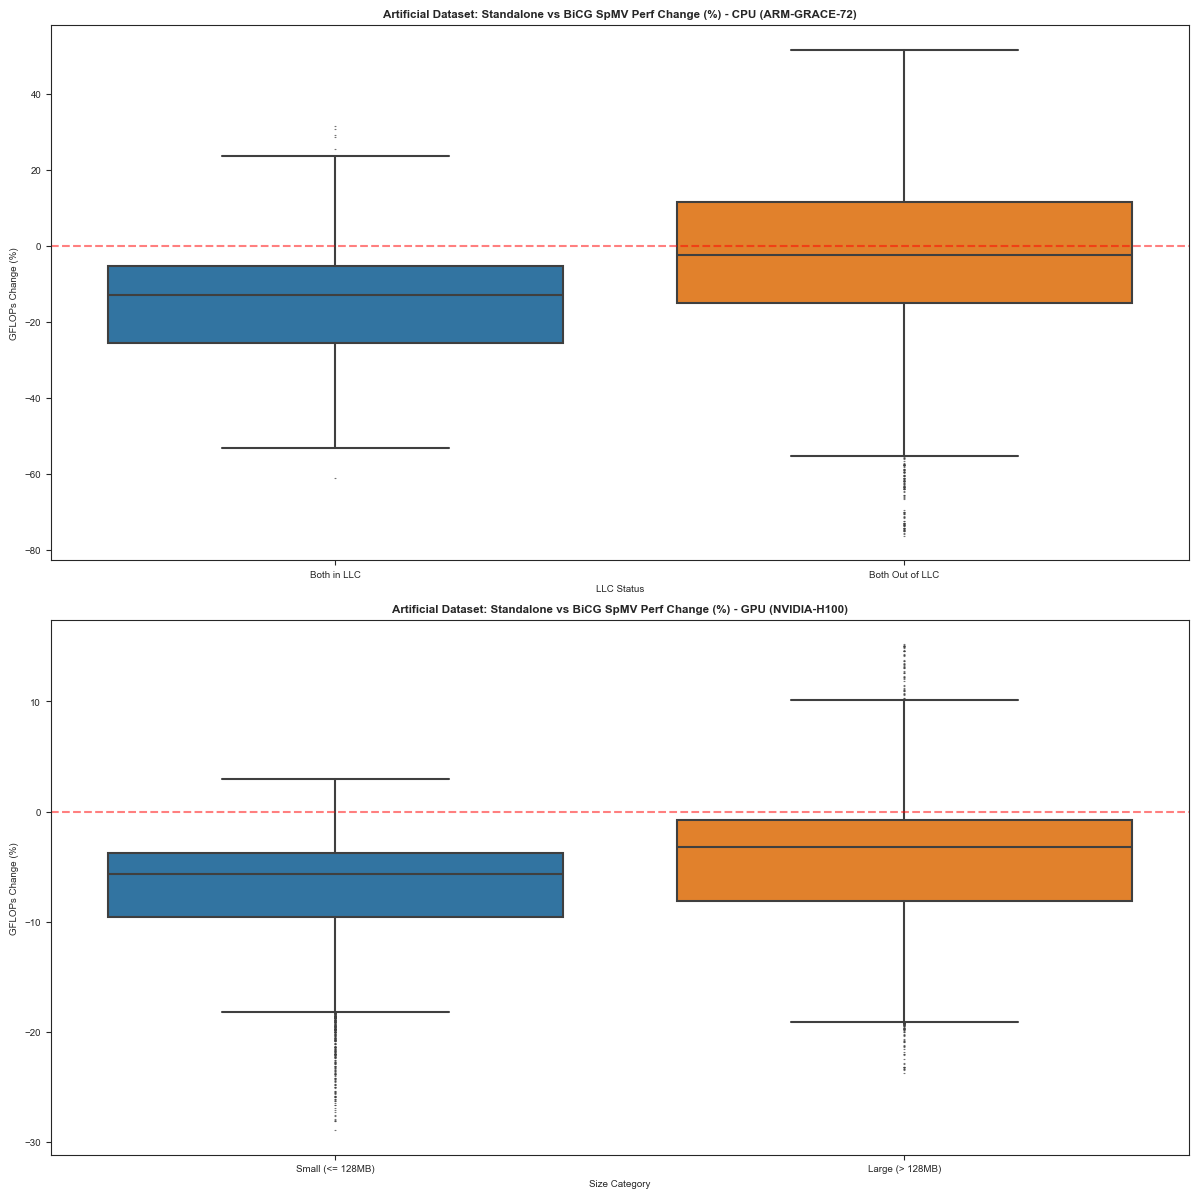

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

# CPU
df_cpu = df_art_final_all[df_art_final_all['device'] == CPU_DEVICE]
sns.boxplot(ax=axes[0], data=df_cpu, x='cache_category', y='gflops_change_pct', order=['Both in LLC', 'Both Out of LLC'])
axes[0].set_title(f"Artificial Dataset: Standalone vs BiCG SpMV Perf Change (%) - CPU ({CPU_DEVICE})", fontweight='bold')
axes[0].set_xlabel("LLC Status")
axes[0].set_ylabel("GFLOPs Change (%)")
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)

# GPU
df_gpu = df_art_final_all[df_art_final_all['device'] == GPU_DEVICE]
sns.boxplot(ax=axes[1], data=df_gpu, x='cache_category', y='gflops_change_pct', order=['Small (<= 128MB)', 'Large (> 128MB)'])
axes[1].set_title(f"Artificial Dataset: Standalone vs BiCG SpMV Perf Change (%) - GPU ({GPU_DEVICE})", fontweight='bold')
axes[1].set_xlabel("Size Category")
axes[1].set_ylabel("GFLOPs Change (%)")
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'artificial_performance_change_boxplot.png'), dpi=300)
plt.show()

---
## Performance Change dataframes (medians and percentages per feature range)

In [52]:
def print_distribution_col100(feature, ranges_feature, group_system_best, verbose = True, name='', count_it=False):
    total = group_system_best.shape[0]
    if(verbose):
        print(feature + ' distribution in dataset')
    ndf_row = [name]
    for val in ranges_feature:
        group_system_best_feat = group_system_best[group_system_best[feature]==val]
        cnt = group_system_best_feat.shape[0]
        if(count_it):
            cnt2 = group_system_best.shape[0]
            new_string = str(np.round(cnt/cnt2*100))# + ' GF'
        else:
            new_string = str(int(np.round(group_system_best_feat['standalone_gflops'].median()))) + \
                        " $\\rightarrow$ " + \
                        str(int(np.round(group_system_best_feat['bicg_gflops'].median()))) + \
                        " (" + \
                        str(np.round(group_system_best_feat['bicg_gflops'].median() / group_system_best_feat['standalone_gflops'].median(), 2)) + \
                        ")"
            # str(np.round((group_system_best_feat['bicg_gflops'].median() - group_system_best_feat['standalone_gflops'].median()) / group_system_best_feat['standalone_gflops'].median()*100, 2)) + \
        if(verbose):
            print(val, '\t', cnt,'/', total,'\t', new_string)
        ndf_row.append(new_string)
    return ndf_row

def median_performance_per_feature_range(df, ranges_dev, llc_thresholds = {}):
    features = ['mem_range', 'anr_categ', 'skew_categ', 'regularity']
    rangess = [ranges_memr, ranges_anr, ranges_skew, ranges_regularity]

    for cnt in range(len(features)):
        feat, ranges_feat = features[cnt], rangess[cnt]
        print(feat)

        new_df_list = []
        df_system_list=[]
        for system in ranges_dev:
            df_sys = df[df['device']==system]
            
            is_cpu=False
            if((system=='AMD-EPYC-64') or (system=='INTEL-SAPPHIRE-56') or (system=='ARM-GRACE-72')):
                is_cpu=True
            
            if(feat != 'mem_range') and (is_cpu):
                df_sys_l = df_sys[df_sys['mem_footprint'] < CPU_LLC_LIMIT].reset_index()
                ndf_row = print_distribution_col100(feat, ranges_feat, df_sys_l, verbose=False, name=system + ' (<LLC)')
                new_df_list.append(ndf_row)
                df_sys_h = df_sys[df_sys['mem_footprint'] > CPU_LLC_LIMIT].reset_index()
                ndf_row = print_distribution_col100(feat, ranges_feat, df_sys_h, verbose=False, name=system + ' (>LLC)')
                new_df_list.append(ndf_row)
            else:
                ndf_row = print_distribution_col100(feat, ranges_feat, df_sys, verbose=False, name=system)
                new_df_list.append(ndf_row)            
        
        extra_ndf_row = print_distribution_col100(feat, ranges_feat, df_sys, verbose=False, name='% dataset', count_it=True)
        new_df_list.append(extra_ndf_row)

        new_df = pd.DataFrame(new_df_list, columns = ['System'] + ranges_feat)
        if(new_df.shape[0]>0):
            new_df.set_index('System', inplace=True)
            new_df = new_df.T
            display(new_df)

df = df_art_final_all.copy()
ranges_dev = ['NVIDIA-H100', 'ARM-GRACE-72']
median_performance_per_feature_range(df, ranges_dev, llc_thresholds = {})

mem_range


System,NVIDIA-H100,ARM-GRACE-72,% dataset
[4-8],60 $\rightarrow$ 57 (0.96),55 $\rightarrow$ 50 (0.91),4.0
[8-16],128 $\rightarrow$ 123 (0.96),108 $\rightarrow$ 96 (0.9),13.0
[16-32],210 $\rightarrow$ 192 (0.91),164 $\rightarrow$ 141 (0.86),15.0
[32-64],260 $\rightarrow$ 226 (0.87),184 $\rightarrow$ 150 (0.82),5.0
[64-128],378 $\rightarrow$ 364 (0.96),141 $\rightarrow$ 95 (0.67),2.0
[128-256],394 $\rightarrow$ 381 (0.97),93 $\rightarrow$ 74 (0.8),12.0
[256-512],415 $\rightarrow$ 390 (0.94),56 $\rightarrow$ 54 (0.98),14.0
[512-1024],420 $\rightarrow$ 389 (0.93),47 $\rightarrow$ 47 (1.01),13.0
[1024-2048],425 $\rightarrow$ 396 (0.93),44 $\rightarrow$ 46 (1.04),20.0


anr_categ


System,NVIDIA-H100,ARM-GRACE-72 (<LLC),ARM-GRACE-72 (>LLC),% dataset
[0-10],222 $\rightarrow$ 185 (0.83),108 $\rightarrow$ 72 (0.66),41 $\rightarrow$ 33 (0.8),19.0
[10-50],311 $\rightarrow$ 295 (0.95),131 $\rightarrow$ 98 (0.75),46 $\rightarrow$ 44 (0.95),33.0
[50-100],349 $\rightarrow$ 340 (0.98),147 $\rightarrow$ 131 (0.89),51 $\rightarrow$ 56 (1.1),17.0
[100-510],368 $\rightarrow$ 371 (1.01),155 $\rightarrow$ 141 (0.91),55 $\rightarrow$ 64 (1.15),30.0


skew_categ


System,NVIDIA-H100,ARM-GRACE-72 (<LLC),ARM-GRACE-72 (>LLC),% dataset
[0-1.5],161 $\rightarrow$ 156 (0.97),121 $\rightarrow$ 100 (0.83),97 $\rightarrow$ 116 (1.19),9.0
[1.5-50],321 $\rightarrow$ 300 (0.93),140 $\rightarrow$ 107 (0.76),48 $\rightarrow$ 50 (1.03),23.0
[50-250],321 $\rightarrow$ 298 (0.93),136 $\rightarrow$ 108 (0.8),51 $\rightarrow$ 55 (1.07),28.0
[250-3000],326 $\rightarrow$ 299 (0.92),133 $\rightarrow$ 100 (0.75),49 $\rightarrow$ 52 (1.08),25.0
[3000-10000],355 $\rightarrow$ 320 (0.9),122 $\rightarrow$ 83 (0.68),45 $\rightarrow$ 44 (0.98),16.0


regularity


System,NVIDIA-H100,ARM-GRACE-72 (<LLC),ARM-GRACE-72 (>LLC),% dataset
SS,276 $\rightarrow$ 266 (0.97),118 $\rightarrow$ 82 (0.7),46 $\rightarrow$ 44 (0.96),32.0
SL,380 $\rightarrow$ 343 (0.9),132 $\rightarrow$ 96 (0.73),48 $\rightarrow$ 50 (1.05),21.0
LS,360 $\rightarrow$ 314 (0.87),140 $\rightarrow$ 117 (0.84),51 $\rightarrow$ 56 (1.09),24.0
LL,282 $\rightarrow$ 254 (0.9),140 $\rightarrow$ 121 (0.87),54 $\rightarrow$ 57 (1.06),22.0


---
## Performance Change 

---
## Performance Change vs. Memory Footprint Category (simple) (plot for TACO paper)

In [61]:
plt.rcParams['font.family'] = 'Times New Roman'
def plot_perf_change_vs_feature_simple(feature_col, order_list, feature_name, save_name):
    font = 7 # ACM standard plot font size
    # original for IEEE paper
    width = 3.487
    # height = .65*width/1.618
    height = .95*width/1.618
    # ratio=1.2
    ratio=1

    fig, ax = plt.subplots(1, 1, figsize=(ratio*width, ratio*height))

    # sns.boxplot(ax=ax, data=df_art_final_all, x=feature_col, y='gflops_change_pct', hue='device', hue_order=['NVIDIA-H100', 'ARM-GRACE-72'], palette=['#4daf4a', '#ff7f00'], order=order_list, linewidth=0.5, width=0.8, )
    sns.boxplot(ax=ax, data=df_art_final_all, x=feature_col, y='perf_ratio', hue='device', hue_order=['NVIDIA-H100', 'ARM-GRACE-72'], palette=['#4daf4a', '#ff7f00'], order=order_list, linewidth=0.5, width=0.8, )
    ax.set_xlabel(feature_name, fontsize=font)
    
    # ax.set_ylabel("Perf Change (%)", fontsize=font)
    # ax.set_ylabel("SpMV Perf. Change (%)", fontsize=font)
    ax.set_ylabel("Relative Performance", fontsize=font)

    # ax.axhline(0, color='red', linestyle='-', alpha=0.3, linewidth = 1)
    ax.axhline(1, color='red', linestyle='-', alpha=0.3, linewidth = 1)
    ax.tick_params(axis='both', which='major', labelsize=font)
    ax.tick_params(axis='both', which='minor', labelsize=font)
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, 0.95), ncol=2, frameon=False, fontsize=font)

    plt.subplots_adjust(left=0.18, bottom=0.12, right=0.98, top=0.88, wspace=0, hspace=0)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=20)
    # plt.setp(ax.xaxis.get_majorticklabels(), rotation=0)

    plt.tight_layout()
    fig_name = os.path.join(PLOT_DIR, save_name)
    plt.savefig(fig_name, bbox_inches='tight')
    # plt.show()
    plt.close()
    
    subprocess.run(['pdfcrop', fig_name], stdout = subprocess.DEVNULL, stderr = subprocess.DEVNULL)
    subprocess.run(['mv', fig_name.replace('.pdf', '-crop.pdf'), fig_name])

# plot_perf_change_vs_feature_simple('mem_range', ranges_memr, 'Memory Footprint (MB)', 'artificial_bicg_perf_change_vs_mem_range.pdf')
plot_perf_change_vs_feature_simple('mem_range', ranges_memr, 'Memory Footprint (MB)', 'artificial_bicg_rel_perf_vs_mem_range.pdf')


In [27]:
def plot_perf_change_vs_feature(feature_col, order_list, feature_name, save_name):
    fig, axes = plt.subplots(2, 1, figsize=(14, 12))
    
    # CPU
    df_cpu = df_art_final_all[df_art_final_all['device'] == CPU_DEVICE]
    sns.boxplot(ax=axes[0], data=df_cpu, x=feature_col, y='gflops_change_pct', hue='cache_category', palette=cpu_colors, order=order_list)
    axes[0].set_title(f"Artificial Dataset: Perf Change (%) by {feature_name} - CPU ({CPU_DEVICE})", fontweight='bold')
    axes[0].set_xlabel(feature_name)
    axes[0].set_ylabel("GFLOPs Change (%)")
    axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)
    
    # GPU
    df_gpu = df_art_final_all[df_art_final_all['device'] == GPU_DEVICE]
    sns.boxplot(ax=axes[1], data=df_gpu, x=feature_col, y='gflops_change_pct', hue='cache_category', palette=gpu_colors, order=order_list)
    axes[1].set_title(f"Artificial Dataset: Perf Change (%) by {feature_name} - GPU ({GPU_DEVICE})", fontweight='bold')
    axes[1].set_xlabel(feature_name)
    axes[1].set_ylabel("GFLOPs Change (%)")
    axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, save_name), dpi=300)
    plt.show()

---
## Performance Change vs. Memory Footprint Category

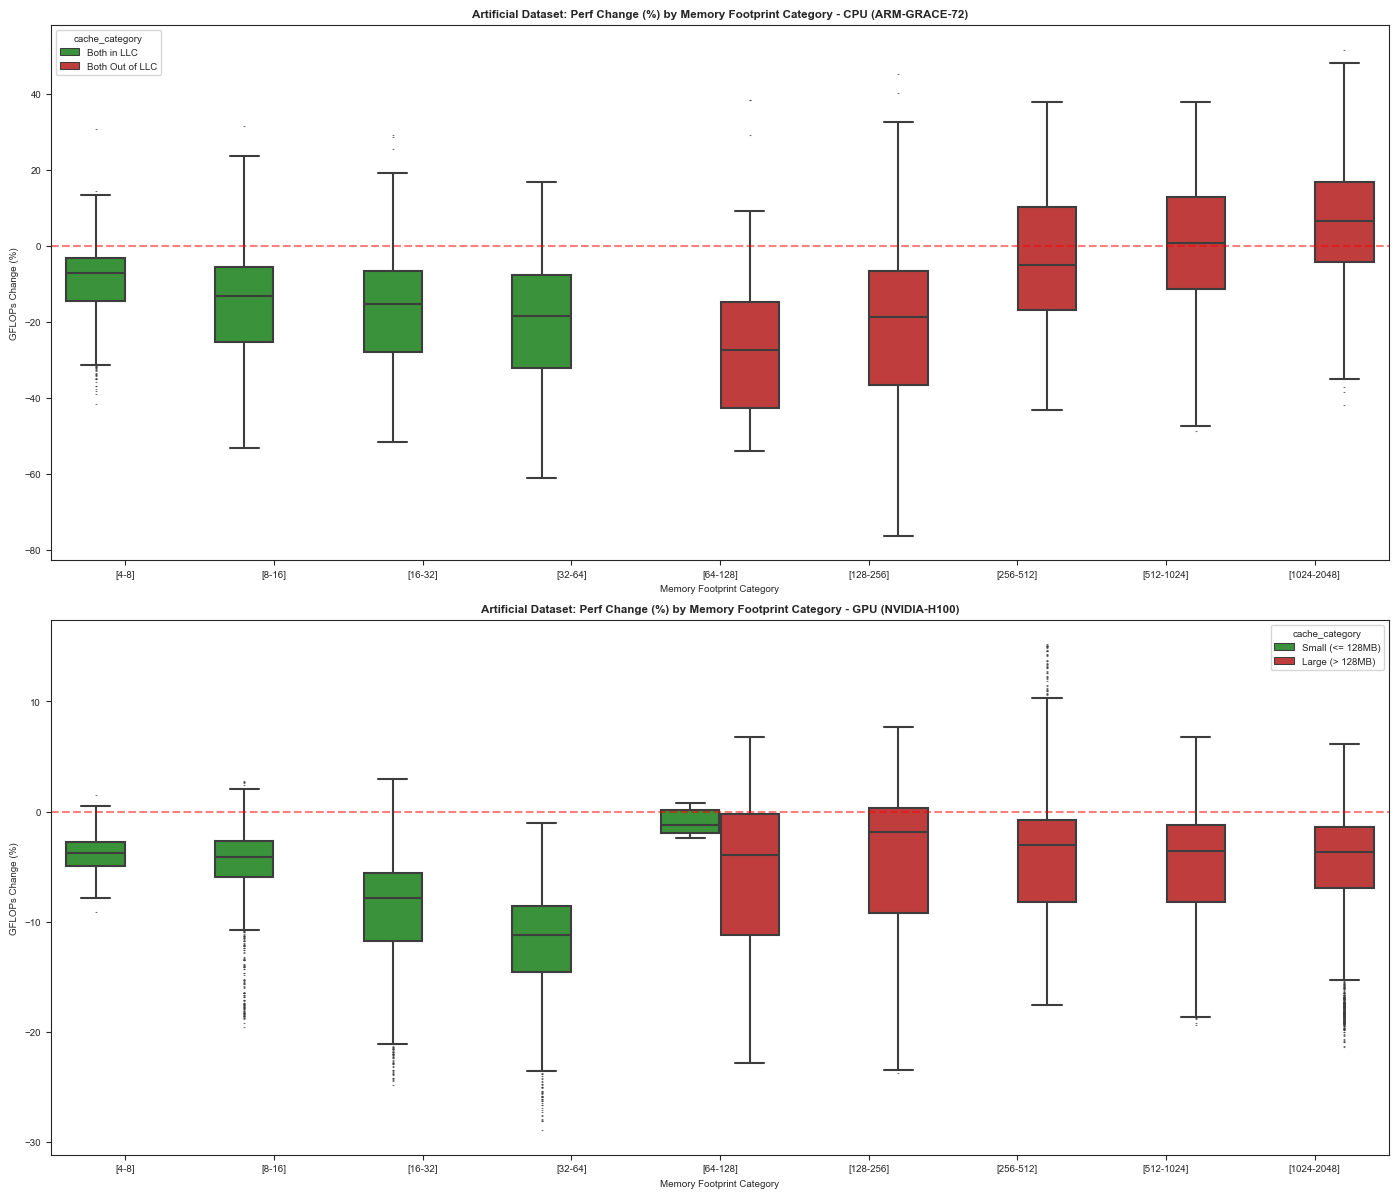

In [28]:
plot_perf_change_vs_feature('mem_range', ranges_memr, 'Memory Footprint Category', 'artificial_performance_change_vs_mem_range.png')

---
## Performance Change vs. Average NNZ per Row

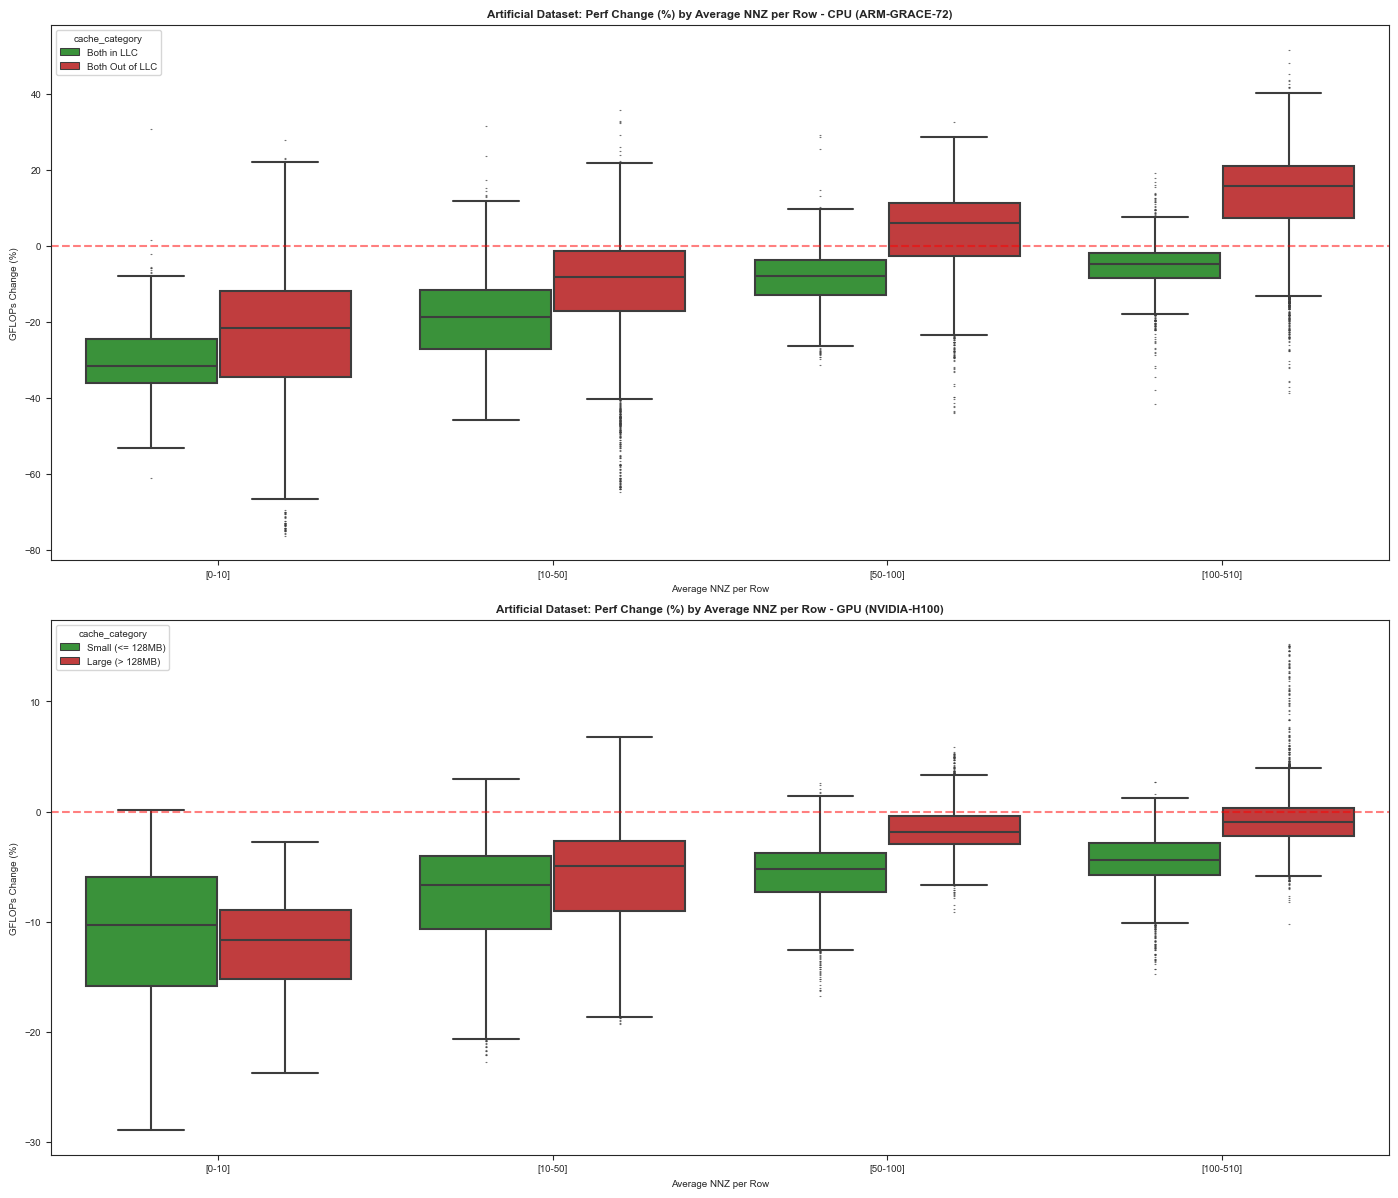

In [29]:
plot_perf_change_vs_feature('anr_categ', ranges_anr, 'Average NNZ per Row', 'artificial_performance_change_vs_anr.png')

---
## Performance Change vs. Skew Coefficient

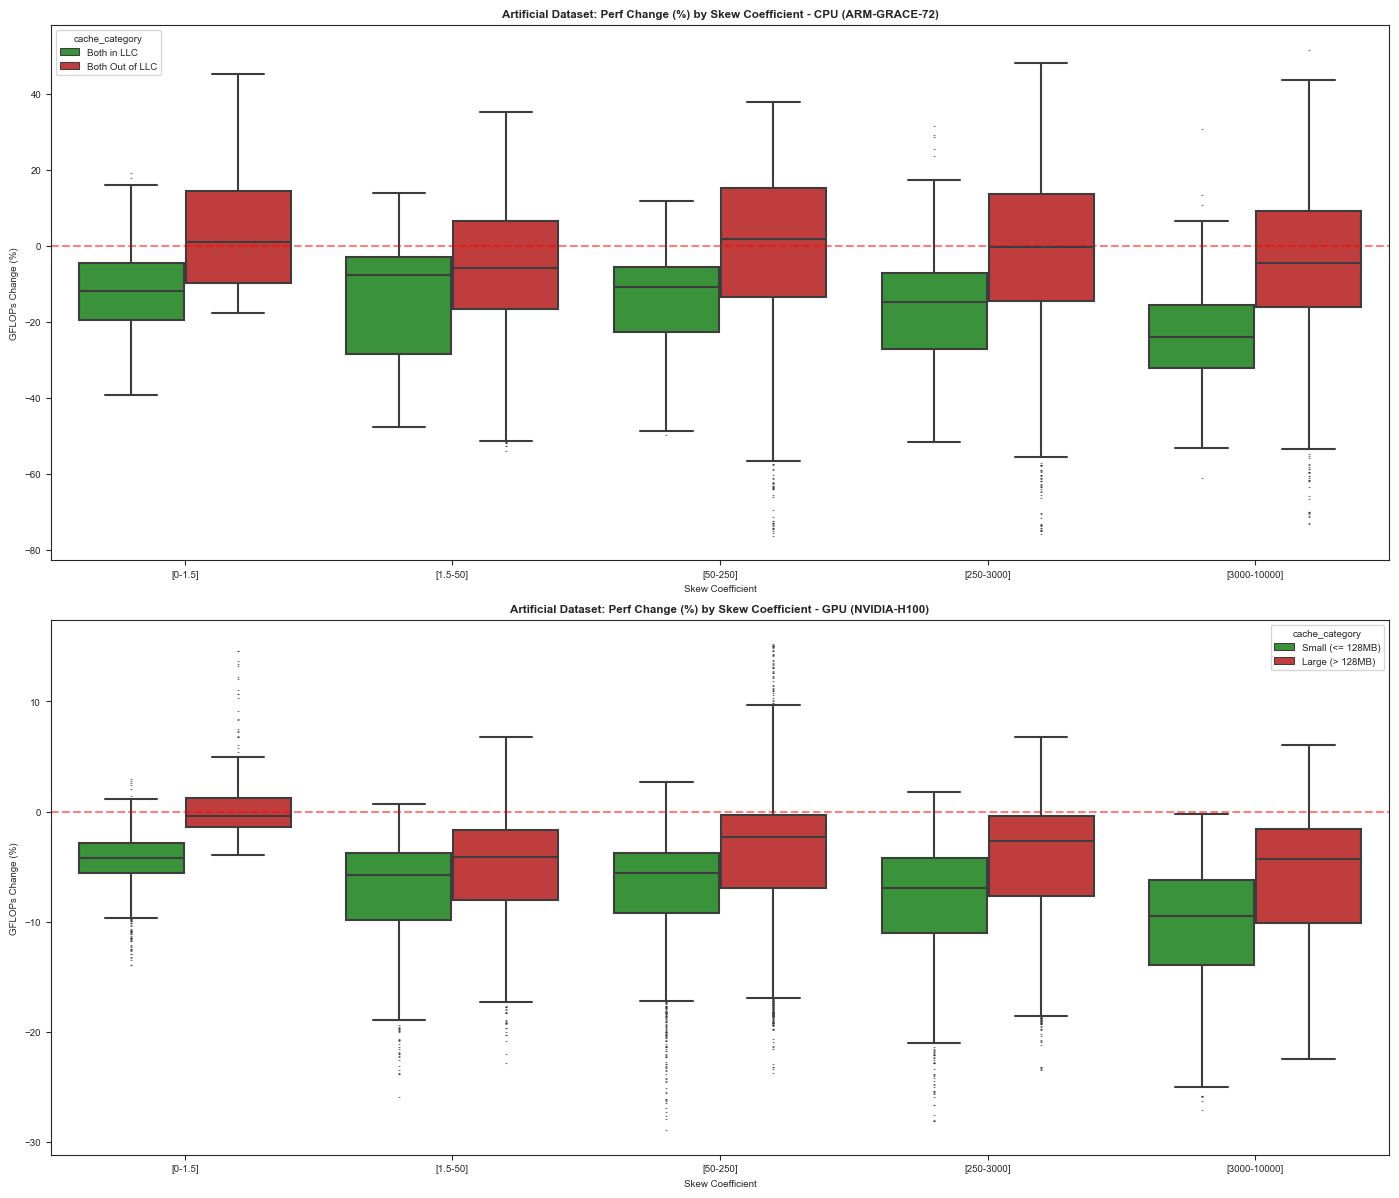

In [30]:
plot_perf_change_vs_feature('skew_categ', ranges_skew, 'Skew Coefficient', 'artificial_performance_change_vs_skew.png')

---
## Performance Change vs. Regularity

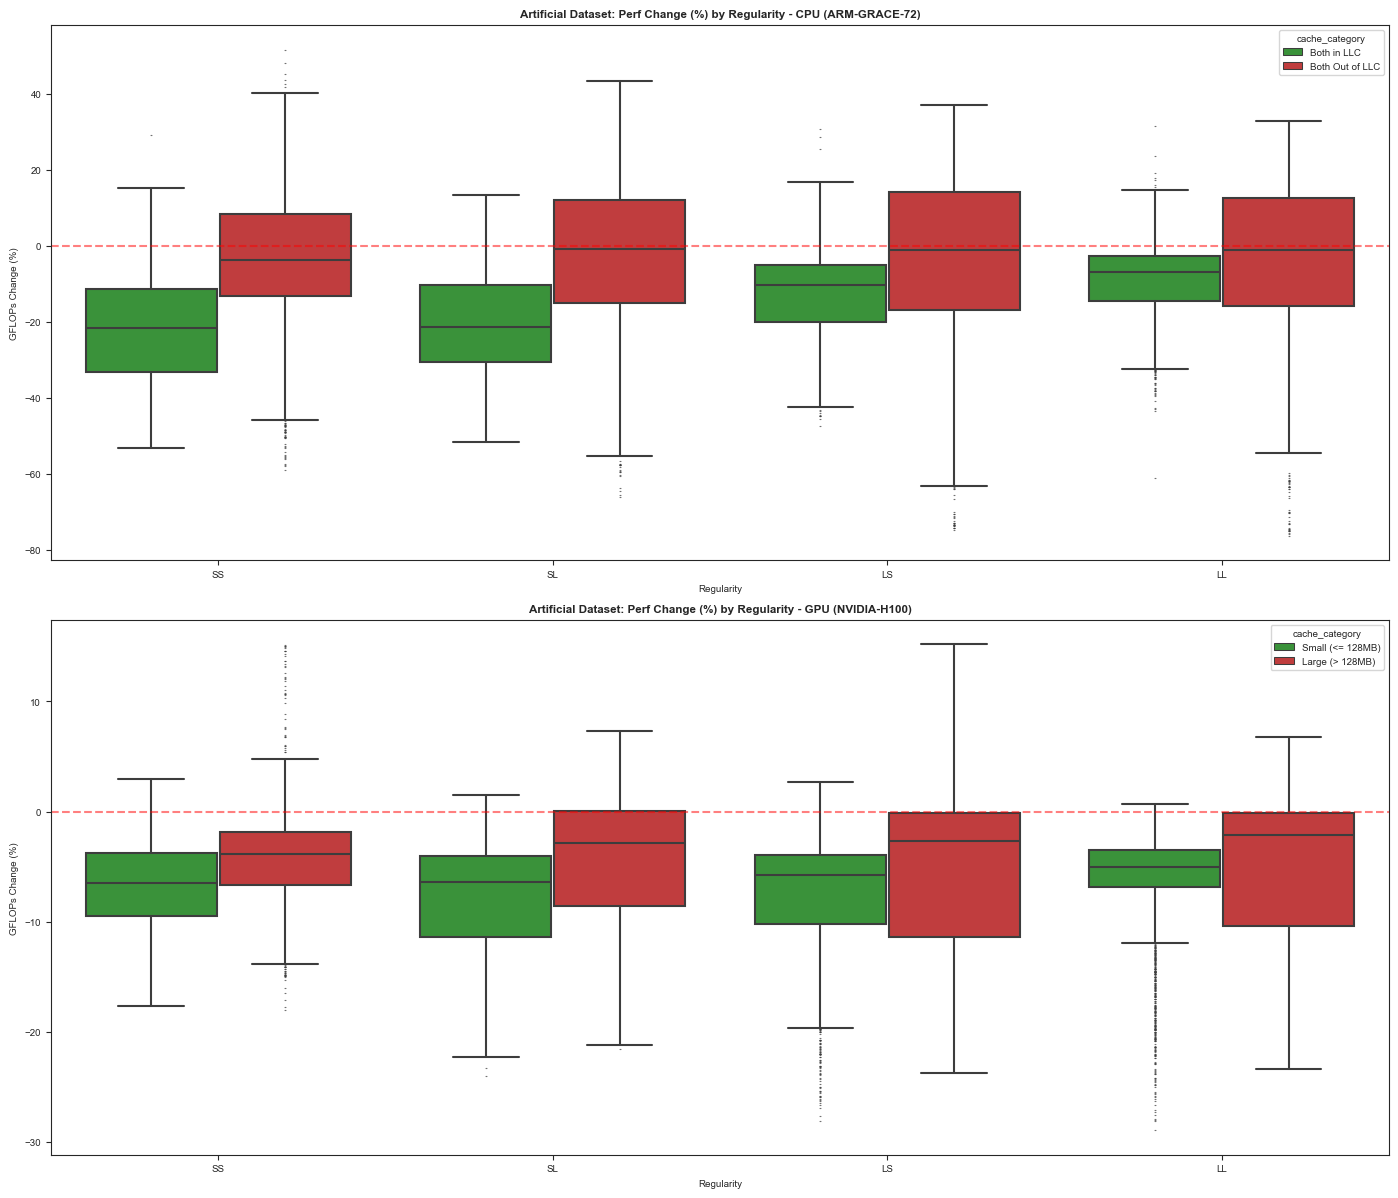

In [31]:
plot_perf_change_vs_feature('regularity', ranges_regularity, 'Regularity', 'artificial_performance_change_vs_regularity.png')

In [32]:
cpu_cache_handles = [
    mpatches.Patch(color='#2ca02c', label='Both in LLC (<= 114MB)'),
    mpatches.Patch(color='#d62728', label='Both Out of LLC (> 114MB)')
]
gpu_cache_handles = [
    mpatches.Patch(color='#2ca02c', label='Small (<= 128MB)'),
    mpatches.Patch(color='#d62728', label='Large (> 128MB)')
]
measurement_handles = [
    mpatches.Patch(facecolor='white', edgecolor='black', label='Standalone SpMV (Solid)'),
    mpatches.Patch(facecolor='white', edgecolor='black', hatch='//', label='BiCG SpMV (Hatched)')
]

def apply_dual_legend_and_hatch(ax, is_gpu):
    legend = ax.get_legend()
    legend_patches = []
    if legend:
        legend_patches = getattr(legend, 'legend_handles', getattr(legend, 'legendHandles', []))
    boxes = [p for p in ax.patches if isinstance(p, mpatches.PathPatch) and p not in legend_patches]
    for idx_box, box in enumerate(boxes):
        if idx_box % 2 == 1:
            box.set_hatch('//')
            
    handles = gpu_cache_handles if is_gpu else cpu_cache_handles
    first_legend = ax.legend(handles=handles, title='Size Category' if is_gpu else 'LLC Residency Status', loc='upper right', fontsize=10, title_fontsize=11)
    ax.add_artist(first_legend)
    ax.legend(handles=measurement_handles, title='Measurement Type', loc='upper left', fontsize=10, title_fontsize=11)

def plot_gflops_vs_feature(feature_col, order_list, feature_name, save_name):
    fig, axes = plt.subplots(2, 1, figsize=(14, 14))
    
    # CPU Combined Hue Group
    df_cpu = df_gflops_melted[df_gflops_melted['device'] == CPU_DEVICE].copy()
    df_cpu['hue_group'] = df_cpu['cache_category'] + " - " + df_cpu['Measurement_Type']
    cpu_color_map = {
        'Both in LLC - Standalone SpMV': '#2ca02c',
        'Both in LLC - BiCG SpMV': '#2ca02c',
        'Both Out of LLC - Standalone SpMV': '#d62728',
        'Both Out of LLC - BiCG SpMV': '#d62728'
    }
    cpu_hue_order = [
        'Both in LLC - Standalone SpMV', 'Both in LLC - BiCG SpMV',
        'Both Out of LLC - Standalone SpMV', 'Both Out of LLC - BiCG SpMV'
    ]
    sns.boxplot(ax=axes[0], data=df_cpu, x=feature_col, y='GFLOPs', hue='hue_group', palette=cpu_color_map, hue_order=cpu_hue_order, order=order_list)
    apply_dual_legend_and_hatch(axes[0], False)
    axes[0].set_title(f"Artificial Dataset: Standalone vs BiCG SpMV GFLOPs by {feature_name} - CPU ({CPU_DEVICE})", fontweight='bold')
    axes[0].set_xlabel(feature_name)
    axes[0].set_ylabel("GFLOPs")
    
    # GPU Combined Hue Group
    df_gpu = df_gflops_melted[df_gflops_melted['device'] == GPU_DEVICE].copy()
    df_gpu['hue_group'] = df_gpu['cache_category'] + " - " + df_gpu['Measurement_Type']
    gpu_color_map = {
        'Small (<= 128MB) - Standalone SpMV': '#2ca02c',
        'Small (<= 128MB) - BiCG SpMV': '#2ca02c',
        'Large (> 128MB) - Standalone SpMV': '#d62728',
        'Large (> 128MB) - BiCG SpMV': '#d62728'
    }
    gpu_hue_order = [
        'Small (<= 128MB) - Standalone SpMV', 'Small (<= 128MB) - BiCG SpMV',
        'Large (> 128MB) - Standalone SpMV', 'Large (> 128MB) - BiCG SpMV'
    ]
    sns.boxplot(ax=axes[1], data=df_gpu, x=feature_col, y='GFLOPs', hue='hue_group', palette=gpu_color_map, hue_order=gpu_hue_order, order=order_list)
    apply_dual_legend_and_hatch(axes[1], True)
    axes[1].set_title(f"Artificial Dataset: Standalone vs BiCG SpMV GFLOPs by {feature_name} - GPU ({GPU_DEVICE})", fontweight='bold')
    axes[1].set_xlabel(feature_name)
    axes[1].set_ylabel("GFLOPs")
    
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, save_name), dpi=300)
    plt.show()

---
## GFLOPs vs. Memory Footprint Category

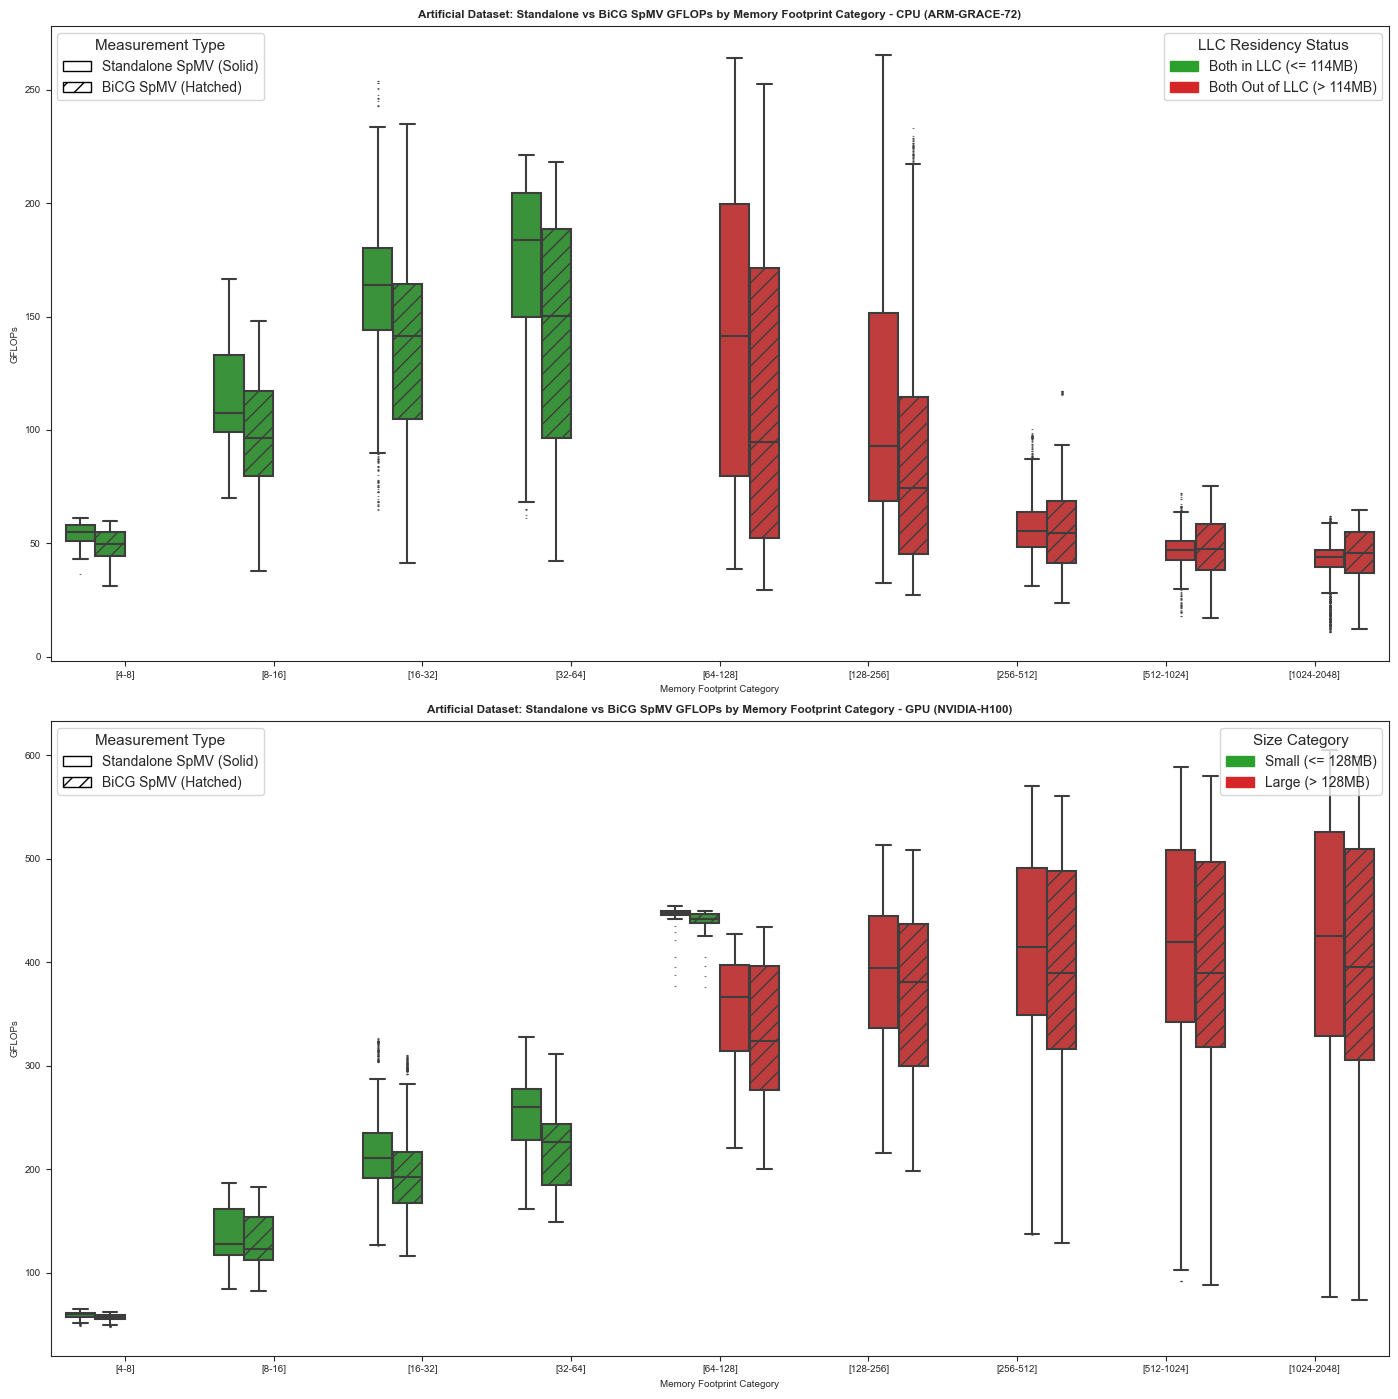

In [33]:
plot_gflops_vs_feature('mem_range', ranges_memr, 'Memory Footprint Category', 'artificial_gflops_comparison_vs_mem_range.png')

---
## GFLOPs vs. Average NNZ per Row

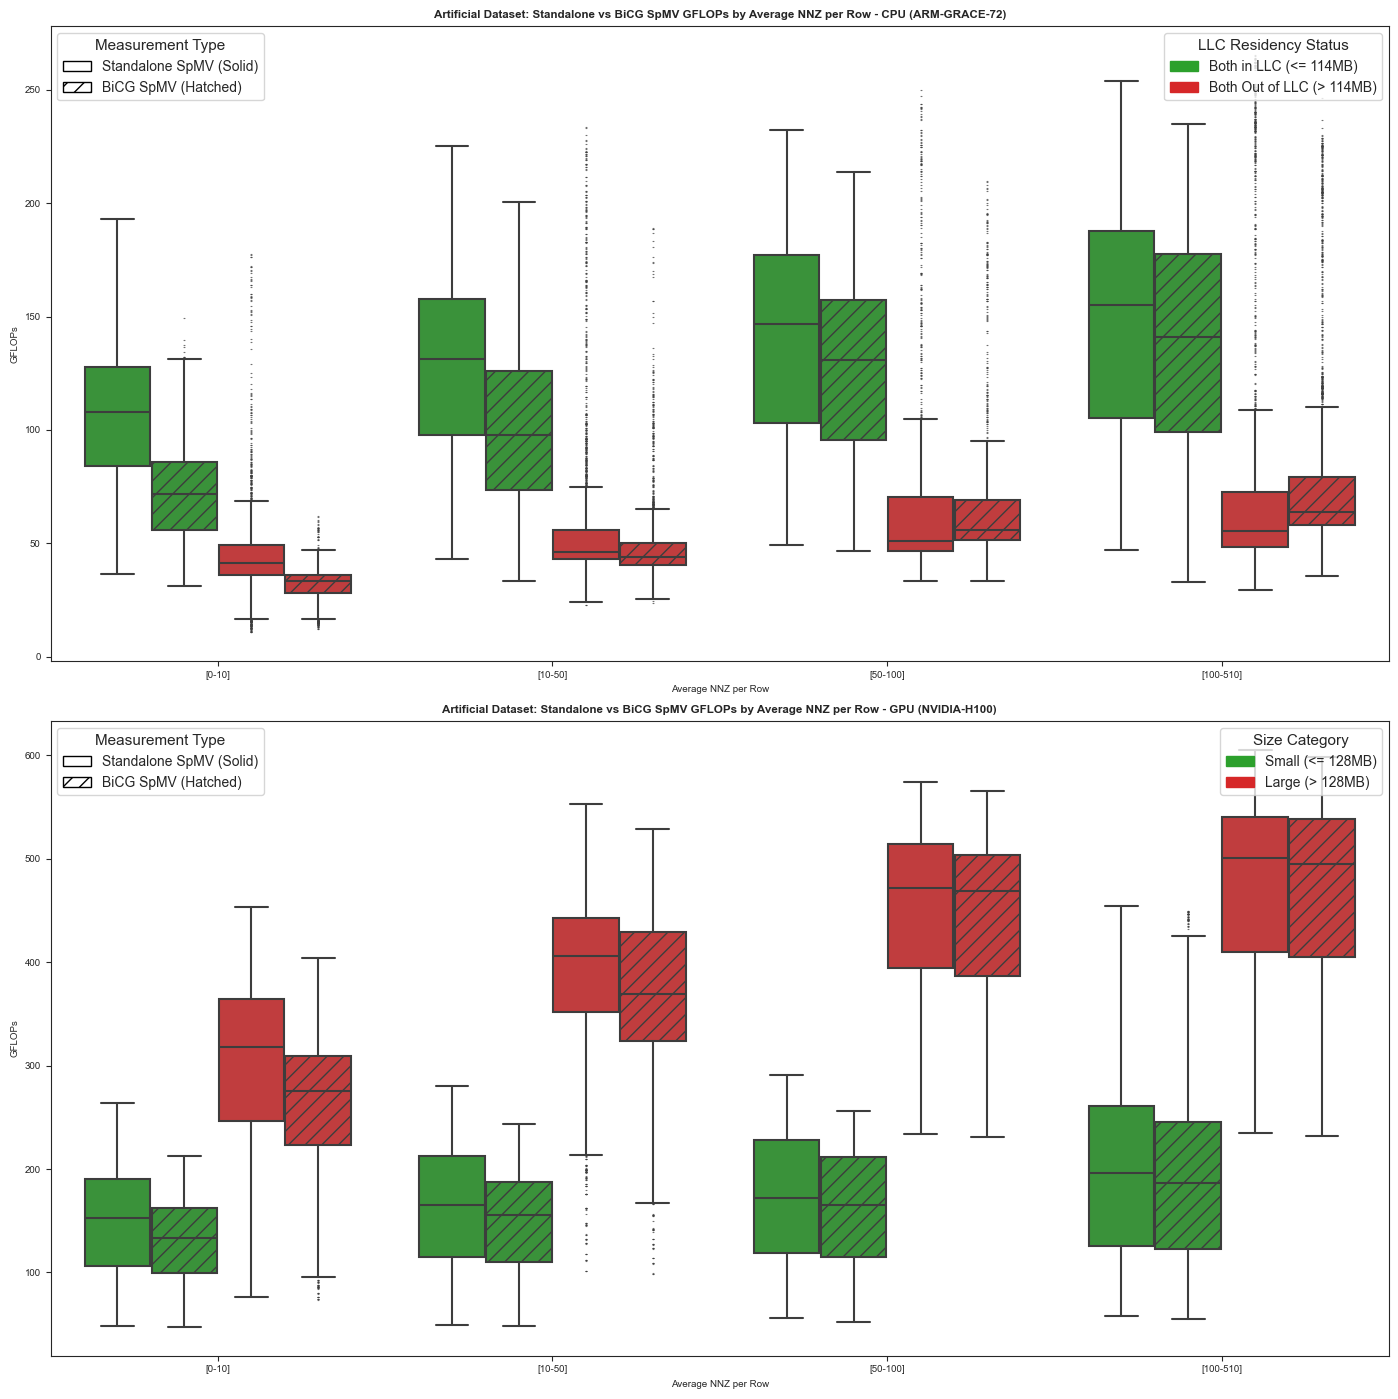

In [34]:
plot_gflops_vs_feature('anr_categ', ranges_anr, 'Average NNZ per Row', 'artificial_gflops_comparison_vs_anr.png')

---
## GFLOPs vs. Skew Coefficient

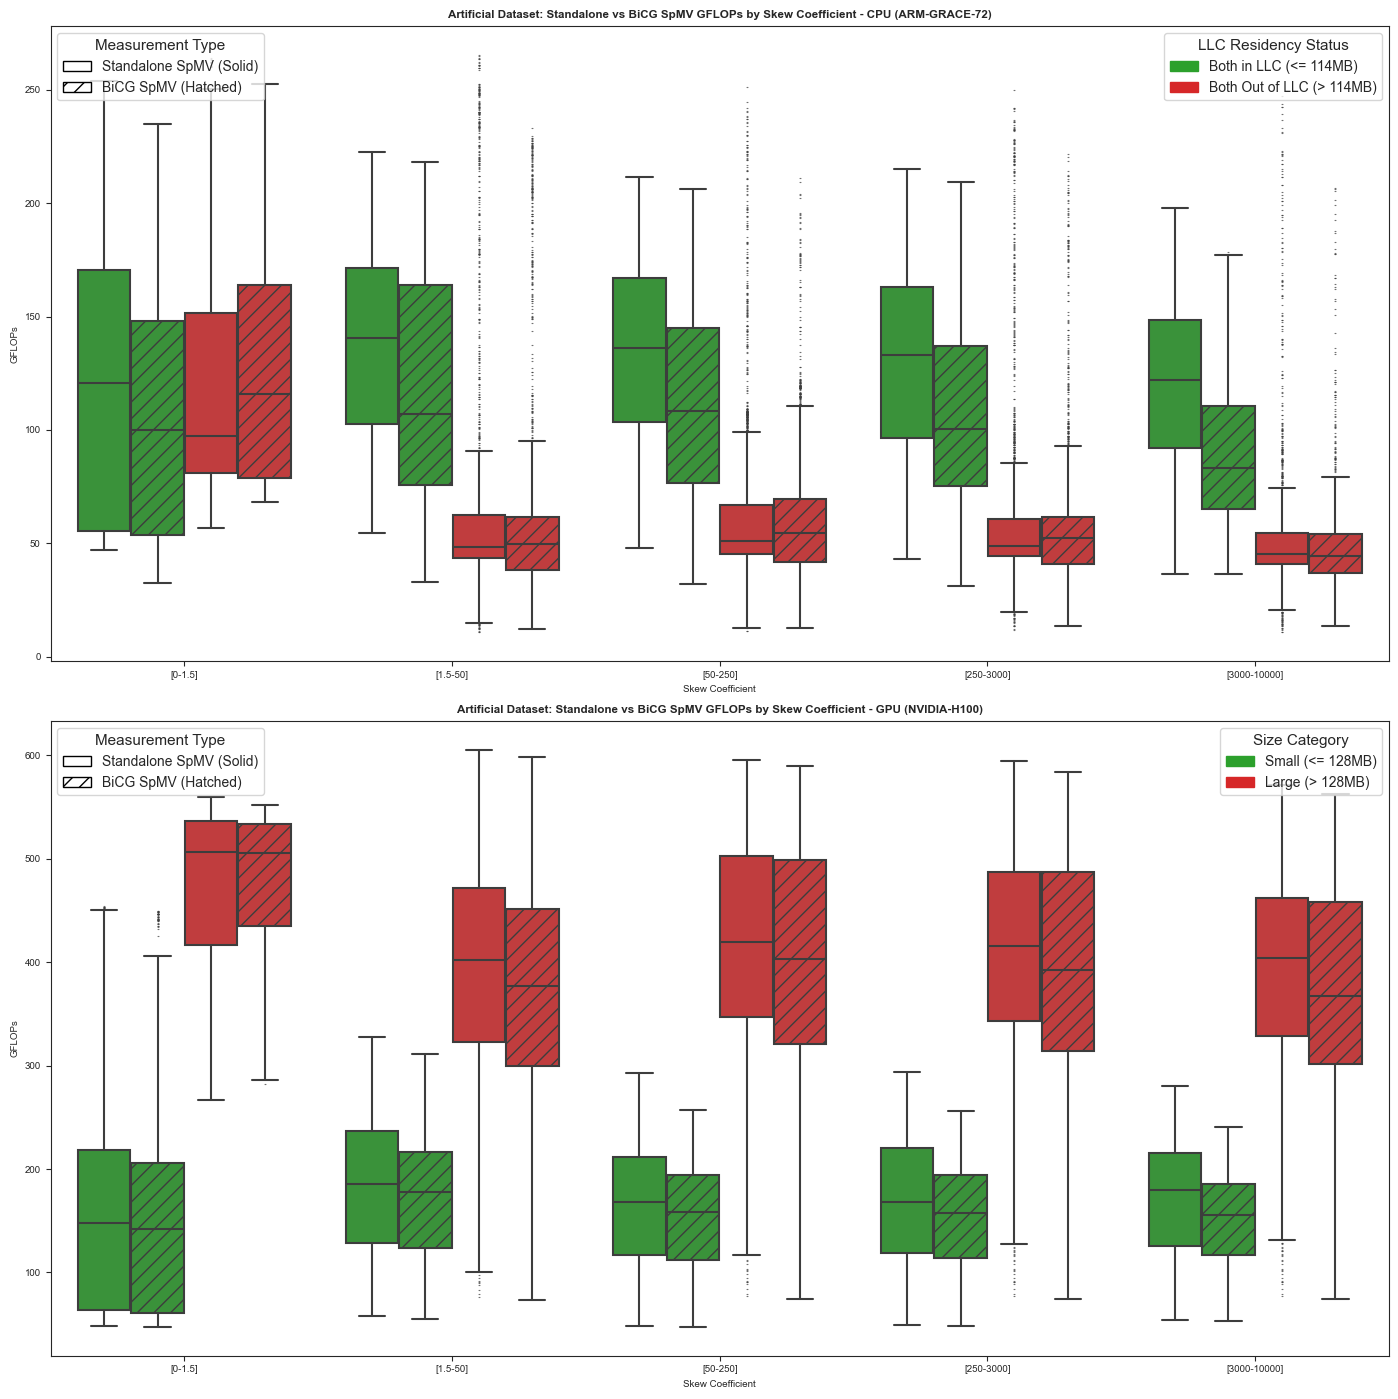

In [35]:
plot_gflops_vs_feature('skew_categ', ranges_skew, 'Skew Coefficient', 'artificial_gflops_comparison_vs_skew.png')

---
## GFLOPs vs. Regularity

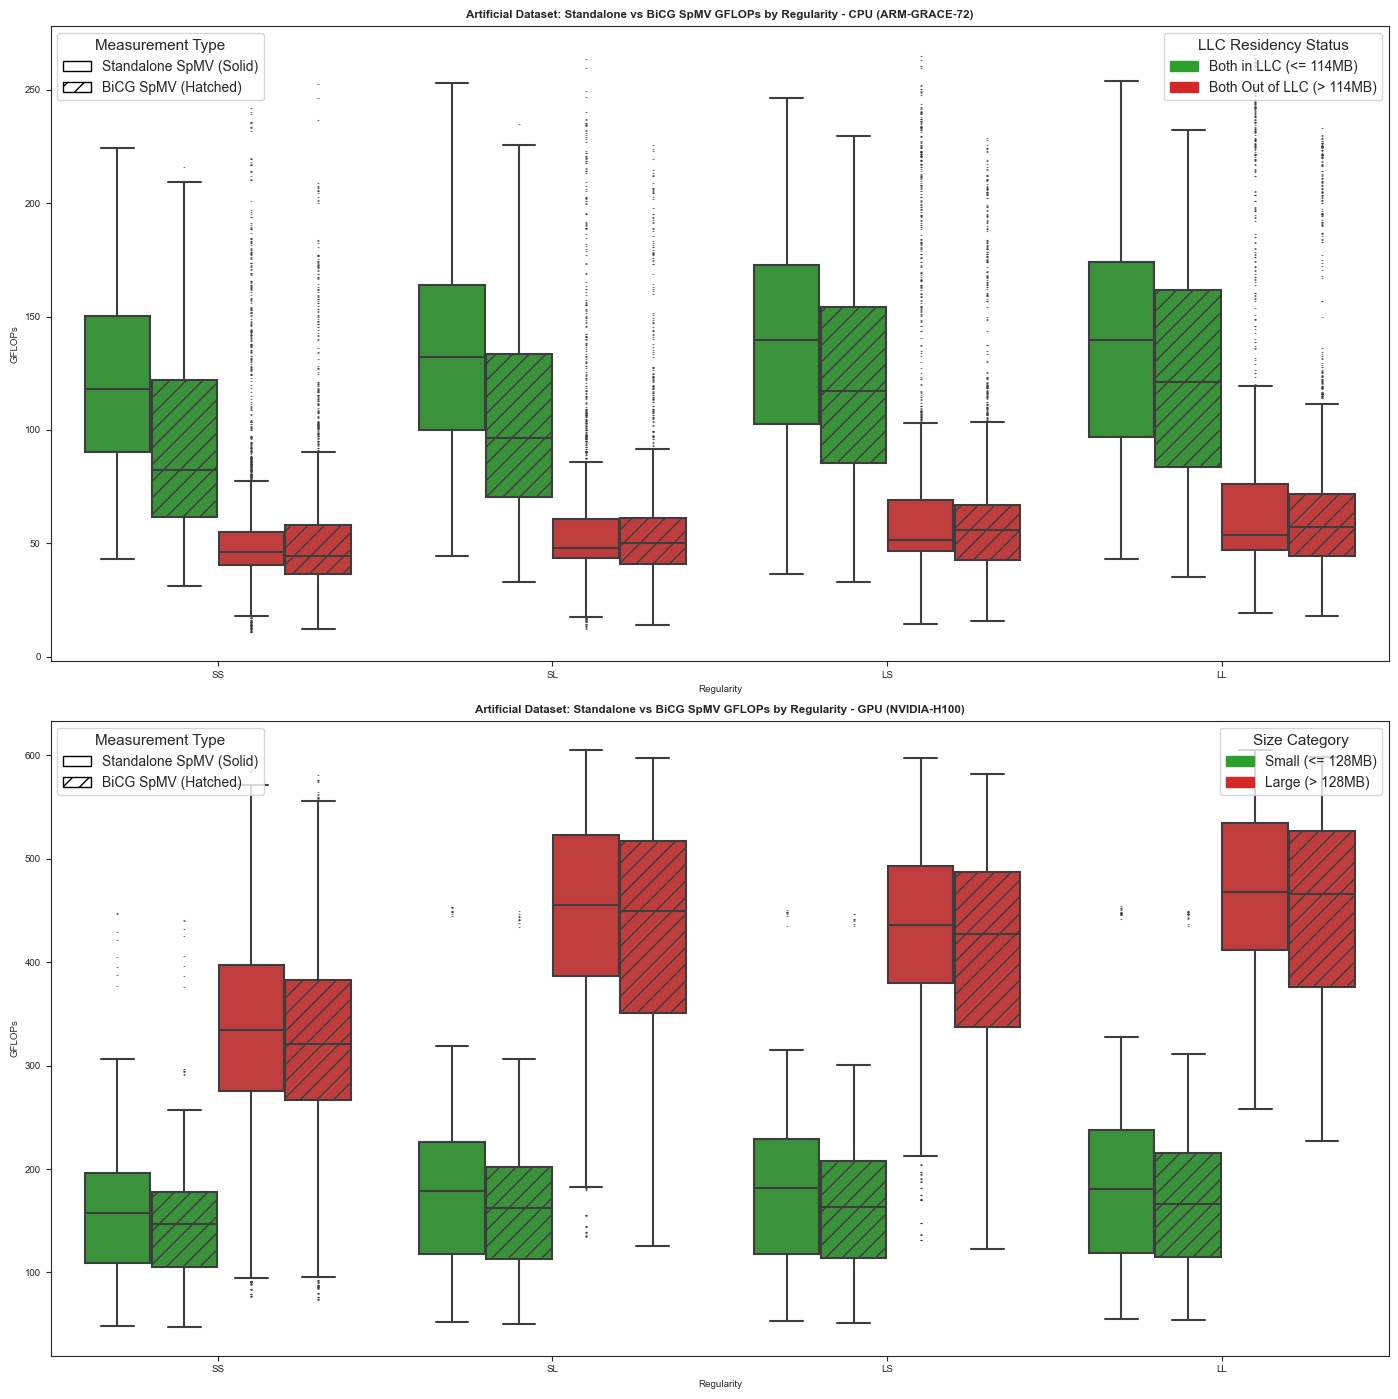

In [36]:
plot_gflops_vs_feature('regularity', ranges_regularity, 'Regularity', 'artificial_gflops_comparison_vs_regularity.png')

---
## Large Artificial Dataset Performance Summarization

Below we generate and display a summary of how SpMV performance inside the BiCG solver is affected on each device architecture for the large synthetic dataset (16,200 matrices).

In [37]:
summary_art = df_art_final_all.groupby(['device', 'cache_category']).agg(
    count=('gflops_change_pct', 'count'),
    mean_gflops_change_pct=('gflops_change_pct', 'mean'),
    median_gflops_change_pct=('gflops_change_pct', 'median'),
    min_gflops_change_pct=('gflops_change_pct', 'min'),
    max_gflops_change_pct=('gflops_change_pct', 'max'),
    mean_perf_ratio=('perf_ratio', 'mean'),
    pct_speedup=('gflops_change_pct', lambda x: (x > 0).sum() / len(x) * 100)
).reset_index()

summary_art.to_csv('spmv_large_art_summary.csv', index=False)
print("Large artificial dataset summary successfully exported to spmv_large_art_summary.csv.")
summary_art

Large artificial dataset summary successfully exported to spmv_large_art_summary.csv.


,device,cache_category,count,mean_gflops_change_pct,median_gflops_change_pct,min_gflops_change_pct,max_gflops_change_pct,mean_perf_ratio,pct_speedup
0,ARM-GRACE-72,Both Out of LLC,9713,-3.6875,-2.3518,-76.2369,51.6280,0.9631,46.0311
1,ARM-GRACE-72,Both in LLC,6477,-15.7192,-12.9827,-61.1632,31.6674,0.8428,5.3574
2,NVIDIA-H100,Large (> 128MB),9668,-4.5869,-3.1889,-23.7268,15.1862,0.9541,16.7356
3,NVIDIA-H100,Small (<= 128MB),6522,-7.1606,-5.6540,-28.9901,2.9460,0.9284,1.0426
